<h1>GuSTO Astrobee (official_template)</h1>

# CVXpy

This template does not take in account time dilation.
$$
\renewcommand{\bm}[1]{\boldsymbol{#1}}
$$

<center><img src="https://i.ibb.co/pBDd5MwH/astrobee-obstacles2.png" width="800"></center>

Guidance problem to solve:

$$
\begin{align*}
    \text{min} \quad &\int_{0}^{t_f}||\bm{\tau}(t)||_2^2dt+\int_0^{t_f}||\bm{a}(t)||_2^2dt\\
    \text{s.t.}\quad&
        \dot{\bm{r}}=
        \bm{v}\\
        &\dot{\bm{v}}=
        \frac{1}{m}\bm{F}=\bm{a}\\
        &\dot{\bm{q}}=
        \frac{1}{2}\begin{bmatrix}
        0&-\omega_x&-\omega_y&-\omega_z\\
        \omega_x&0&\omega_z&-\omega_y\\
        \omega_y&-\omega_z&0&\omega_x\\
        \omega_z&\omega_y&-\omega_x&0
        \end{bmatrix}\bm{q}\\
        &\dot{\bm{\omega}}=
        \bm{I}^{-1}(-\bm{\omega}\times\bm{I}\bm{\omega}+\bm{\tau})\\
    &||\bm{r}-\bm{c}_1||\geq d_1,\quad||\bm{r}-\bm{c}_2||\geq d_2,\quad||\bm{r}-\bm{c}_3||\geq d_3\\
    &||\bm{v}||_2\leq v_{\text{max}}\\
    &||\bm{\omega}||_2\leq \omega_{\text{max}}\\
    &||\bm{a}||_1\leq a_{\text{max}}\\
    &||\bm{\tau}||_1\leq\tau_{\text{max}}\\
    &\bm{x}(0)=\bm{x}_0,\quad\bm{x}(t_f)=\bm{x}_{t_f}\\
    &\bm{v}(0)=\bm{v}_0,\quad\bm{v}(t_f)=\bm{v}_{t_f}\\
    &\bm{q}(0)=\bm{q}_0,\quad\bm{q}(t_f)=\bm{q}_{t_f}\\
    &\bm{w}(0)=\bm{w}_0,\quad\bm{\omega}(t_f)=\bm{\omega}_{t_f}
\end{align*}
$$

Given the scaling matrices and vectors $\bm{S}_x$, $\bm{S}_u$, $\bm{c}_x$, $\bm{c}_u$:

$$\hat{\bm{u}}=\begin{bmatrix}
\bm{a}\\
\bm{\tau}
\end{bmatrix},\quad\hat{\bm{u}}=\bm{S}_u\bm{u}+\bm{c}_u$$

$$\hat{\bm{x}}=\begin{bmatrix}
\bm{r}\\
\bm{v}\\
\bm{q}\\
\bm{\omega}
\end{bmatrix},\quad\hat{\bm{x}}=\bm{S}_x\bm{x}+\bm{c}_x$$

Where scaling matrices and vectors try to limit the optimization variables within $\bm{x}\in[0, 1]^n$, $\bm{u}\in[0, 1]^m$.

First, the original optimization problem is modeled as follows:
$$
\begin{align*}
    \text{min} \quad &J_\lambda(\bm{x},\bm{u},\bm{v}_c,\bm{v}_i)\\
    \text{s.t.}\quad&
        \dot{\hat{\bm{x}}}=
        \bm{f}(\hat{\bm{x}},\hat{\bm{u}},t)\\
    &\bm{g}(\hat{\bm{x}},t)\leq \bm{0}\\
    &\hat{\bm{x}}\in\mathcal{X},\quad \hat{\bm{u}}\in\mathcal{U}
\end{align*}
$$
Where $\mathcal{X}$, $\mathcal{U}$ encompass convex restrictions.

Via 1st order Taylor series and matrix algebra:

$$
\begin{equation*}
\hat{\bm{A}}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)=\nabla_{\bm{\hat{x}}}\bm{f}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t),\quad
\hat{\bm{B}}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)=\nabla_{\bm{\hat{u}}}\bm{f}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)
\end{equation*}
$$
$$
\begin{equation*}
\hat{\bm{y}}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)=\bm{f}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)-\nabla_{\bm{\hat{x}}}\bm{f}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)\hat{\bar{\bm{x}}}-\nabla_{\bm{\hat{u}}}\bm{f}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)\hat{\bar{\bm{u}}}
\end{equation*}
$$

$$
\begin{equation*}
\hat{\bm{C}}(\hat{\bar{\bm{x}}},t)=\nabla_{\bm{\hat{x}}}\bm{g}(\hat{\bar{\bm{x}}},t)
\end{equation*}
$$
$$
\begin{equation*}
\hat{\bm{z}}(\hat{\bar{\bm{x}}},t)=\bm{g}(\hat{\bar{\bm{x}}},t)-\nabla_{\bm{\hat{x}}}\bm{g}(\hat{\bar{\bm{x}}},t)\hat{\bar{\bm{x}}}
\end{equation*}
$$

Then, original optimization problem is transformed into:

$$
\begin{align*}
    \text{min} \quad &J_\lambda(\bm{x},\bm{u})\\
    \text{s.t.}\quad&
        \dot{\hat{\bm{x}}}=
        \hat{\bm{A}}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)\hat{\bm{x}}+\hat{\bm{B}}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)\hat{\bm{u}}+\hat{\bm{y}}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)+\bm{v}_c\\
    &\hat{\bm{C}}(\hat{\bar{\bm{x}}},t)\hat{\bm{x}}+\hat{\bm{z}}(\hat{\bar{\bm{x}}},t)\leq \bm{0}\\
    &\hat{\bm{x}}\in\mathcal{X},\quad \hat{\bm{u}}\in\mathcal{U}
\end{align*}
$$

Defining:

$$
\begin{equation*}
\bm{A}=\bm{S}_x^{-1}\hat{\bm{A}}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)\bm{S}_x,\quad \bm{B}=\bm{S}_x^{-1}\hat{\bm{B}}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)\bm{S}_u
\end{equation*}
$$
$$
\begin{equation*}
\bm{y}=\bm{S}_x^{-1}\hat{\bm{A}}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)\bm{c}_x+
\bm{S}_x^{-1}\hat{\bm{B}}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)\bm{c}_u+
\bm{S}_x^{-1}\hat{\bm{y}}(\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}},t)
\end{equation*}
$$

$$
\begin{equation*}
\bm{C}=\hat{\bm{C}}(\hat{\bar{\bm{x}}},t)\bm{S}_x,\quad \bm{D}=\hat{\bm{D}}(\hat{\bar{\bm{x}}},t)\bm{S}_u
\end{equation*}
$$
$$
\begin{equation*}
\bm{z}=\hat{\bm{C}}(\hat{\bar{\bm{x}}},t)\bm{c}_x+
\hat{\bm{D}}(\hat{\bar{\bm{x}}},t)\bm{c}_u+
\hat{\bm{z}}(\hat{\bar{\bm{x}}},t)
\end{equation*}
$$

Some matrix algebra leads to the following optimization problem (we omit $\hat{\bar{\bm{x}}},\hat{\bar{\bm{u}}}$ dependency for notation simplicity):
$$
\begin{align*}
    \text{min} \quad &J_\lambda(\bm{x},\bm{u})\\
    \text{s.t.}\quad&
        \dot{\bm{x}}=
        \bm{A}(t)\bm{x}+\bm{B}(t)\bm{u}+\bm{y}(t)\\
    &\bm{C}(t)\bm{x}+\bm{z}(t)\leq \bm{0}\\
    &\bm{u}\in\mathcal{U}
\end{align*}
$$

Let the Linear Time Varying system (LTV):

$$
\begin{equation*}
    \dot{\bm{x}}(t)=\bm{A}(t)\bm{x}(t)+\bm{B}(t)\bm{u}(t)+\bm{y}(t)
\end{equation*}
$$

For a specific $t \in [t_k,t_{k+1}]$, the exact solution for $\bm{x}$ is given by:

$$
\begin{equation*}
    \bm{x}(t_{k+1})=\bm{\Phi}(t_{k+1},t_k)\bm{x}(t_k)+\int_{t_k}^{t_{k+1}}\Phi(t_{k+1},\xi)\bm{B}(\xi)\bm{u}(\xi)d\xi+\int_{t_k}^{t_{k+1}}\Phi(t_{k+1},\xi)\bm{y}(\xi)d\xi
\end{equation*}
$$

State transition matrix $\bm{\Phi}$ properties lead to:
$$
\begin{equation*}
    \bm{x}(t_{k+1})=\bm{\Phi}(t_{k+1},t_k)\bm{x}(t_k)+\bm{\Phi}(t_{k+1},t_k)\int_{t_k}^{t_{k+1}}\bm{\Phi}^{-1}(\xi,t_k)\bm{B}(\xi)\bm{u}(\xi)d\xi+\bm{\Phi}(t_{k+1},t_k)\int_{t_k}^{t_{k+1}}\bm{\Phi}^{-1}(\xi,t_k)\bm{y}(\xi)d\xi
\end{equation*}
$$

Assuming a First Order Hold condition for $\bm{u}(t)$ with $t\in[t_k,t_{k+1})$:
$$
\begin{equation*}
    \bm{u}(t)=\lambda_{k}^{-}(t)\bm{u}(t_k)+\lambda_{k}^{+}(t)\bm{u}(t_{k+1})
\end{equation*}
$$
$$
\begin{equation*}
    \lambda_{k}^{-}(t):=\frac{t_{k+1}-t}{t_{k+1}-t_k},\quad\lambda_{k}^{+}(t):=\frac{t-t_{k}}{t_{k+1}-t_k}
\end{equation*}
$$

Subsequently:

$$
\begin{gather*}
    \bm{x}(t_{k+1})=\bm{\Phi}(t_{k+1},t_k)\bm{x}(t_k)+\bm{\Phi}(t_{k+1},t_k)\int_{t_k}^{t_{k+1}}\bm{\Phi}^{-1}(\xi,t_k)\bm{B}(\xi)\lambda_{k}^{-}(\xi)d\xi\bm{u}(t_k)+\\ \bm{\Phi}(t_{k+1},t_k)\int_{t_k}^{t_{k+1}}\bm{\Phi}^{-1}(\xi,t_k)\bm{B}(\xi)\lambda_{k}^{+}(\xi)d\xi\bm{u}(t_{k+1})+\bm{\Phi}(t_{k+1},t_k)\int_{t_k}^{t_{k+1}}\bm{\Phi}^{-1}(\xi,t_k)\bm{w}(\xi)d\xi
\end{gather*}
$$

For simplicity denoted as:
$$
\begin{equation*}
    \bm{x}_{k+1}=\bm{A}_k\bm{x}_k+\bm{B}_k^{-}\bm{u}_k+\bm{B}_k^{+}\bm{u}_{k+1}+\bm{y}_k
\end{equation*}
$$
Where:
$$
\begin{equation*}
\bm{A}_k=\bm{\Phi}(t_{k+1},t_k)
\end{equation*}
$$
$$
\begin{equation*}
\bm{B}_{k}^{-}=\bm{\Phi}(t_{k+1},t_k)\int_{t_k}^{t_{k+1}}\bm{\Phi}^{-1}(\xi,t_k)\bm{B}(\xi)\lambda_{k}^{-}(\xi)d\xi,\quad 
\bm{B}_{k}^{+}=\bm{\Phi}(t_{k+1},t_k)\int_{t_k}^{t_{k+1}}\bm{\Phi}^{-1}(\xi,t_k)\bm{B}(\xi)\lambda_{k}^{+}(\xi)d\xi
\end{equation*}
$$
$$
\begin{equation*}
\bm{y}_k=\bm{\Phi}(t_{k+1},t_k)\int_{t_k}^{t_{k+1}}\bm{\Phi}^{-1}(\xi,t_k)\bm{y}(\xi)d\xi
\end{equation*}
$$

To compute these discrete matrices at each sampling instant, the following differential equation corresponding to the state transition matrix is solved successively for each discretization step:

$$
\begin{equation*}
\dot{\bm{\Phi}}(t,t_0)=\bm{A}(t)\bm{\Phi}(t,t_0)
\end{equation*}
$$

In this manner, the full GuSTO convex optimization problem is formulated:

$$
\begin{align*}
    \text{min} \quad &\mathcal{L}_\lambda(\bm{x},\bm{u})\\
    \text{s.t.}\quad&
        \bm{x}_{k+1}=\bm{A}_k\bm{x}_k+\bm{B}_k^{-}\bm{u}_k+\bm{B}_k^{+}\bm{u}_{k+1}+\bm{y}_k\\
    &\bm{C}_{k}\bm{x}_{k}+\bm{z}_{k}\leq \bm{v}_{i_k}\\
    &\bm{u}_k\in\mathcal{U}_k
\end{align*}
$$

This example denotes for instance (not always):
- $\hat{\bm{x}}$ as `hx`(no scaled).
- $\bm{x}$ as `x` (scaled)
- $\bm{x}_k$ as `x[:,k:k+1]` (discrete scaled)
- $\bar{\bm{x}}_k$ as `ox[:,k:k+1]` (discrete scaled old, last generated trajectory)

Libraries:

In [1]:
import numpy as np
import cvxpy as cp
import sympy as sp
import ecos
import math
from scipy.spatial.transform import Rotation as R, Slerp
import time
import re
import matplotlib.pyplot as plt
import plotly.graph_objs as go

The user should input the mathematical optimization problem using Sympy (library for symbolic calculations):

In [2]:
ax, ay, az = sp.symbols('ax ay az')
taux, tauy, tauz = sp.symbols('taux tauy tauz')

t = sp.symbols('t')

rx, ry, rz = sp.symbols('rx ry rz')
vx, vy, vz = sp.symbols('vx vy vz')

q0, q1, q2, q3 = sp.symbols('q0 q1 q2 q3')
wx, wy, wz = sp.symbols('wx wy wz')

Ixx, Iyy, Izz = sp.symbols('Ixx Iyy Izz')
Ixy, Ixz, Iyz = sp.symbols('Ixy Ixz Iyz')

d_obs1, d_obs2, d_obs3 = sp.symbols('d_obs1 d_obs2 d_obs3')
c_obs1_x, c_obs1_y, c_obs1_z = sp.symbols('c_obs1_x c_obs1_y c_obs1_z')
c_obs2_x, c_obs2_y, c_obs2_z = sp.symbols('c_obs2_x c_obs2_y c_obs2_z')
c_obs3_x, c_obs3_y, c_obs3_z = sp.symbols('c_obs3_x c_obs3_y c_obs3_z')

# Rigid body kinematics
I = sp.Matrix([
    [Ixx, Ixy, Ixz],
    [Ixy, Iyy, Iyz],
    [Ixz, Iyz, Izz]
])

w_sympy = sp.Matrix([wx, wy, wz])
tau_sympy = sp.Matrix([taux, tauy, tauz])

f_ridig_body = I.inv() * (- w_sympy.cross(I*w_sympy) + tau_sympy)

f_ridig_body = sp.simplify(f_ridig_body)

f1 = vx
f2 = vy
f3 = vz
f4 = ax
f5 = ay
f6 = az
f7 = 0.5 * (-wx*q1-wy*q2-wz*q3)
f8 = 0.5 * (+wx*q0+wz*q2-wy*q3)
f9 = 0.5 * (+wy*q0-wz*q1+wx*q3)
f10 = 0.5 * (wz*q0+wy*q1-wx*q2)
f11 = f_ridig_body[0]
f12 = f_ridig_body[1]
f13 = f_ridig_body[2]

diff1 = sp.Matrix([rx, ry, rz])-sp.Matrix([c_obs1_x, c_obs1_y, c_obs1_z])
diff2 = sp.Matrix([rx, ry, rz])-sp.Matrix([c_obs2_x, c_obs2_y, c_obs2_z])
diff3 = sp.Matrix([rx, ry, rz])-sp.Matrix([c_obs3_x, c_obs3_y, c_obs3_z])

g1 = -sp.sqrt(diff1.dot(diff1))+d_obs1
g2 = -sp.sqrt(diff2.dot(diff2))+d_obs2
g3 = -sp.sqrt(diff3.dot(diff3))+d_obs3

f_orig_opt_prob=[f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13]
g_orig_opt_prob=[g1,g2,g3]

x_states = [rx,ry,rz,vx,vy,vz,q0,q1,q2,q3,wx,wy,wz]
u_input = [ax,ay,az,taux,tauy,tauz]

states_size = len(x_states)
inputs_size = len(u_input)
non_convex_inequalities_size = len(g_orig_opt_prob)

Compulsory: User also should input the following string vector

In [3]:
state_parameters_string = [
    "rx",
    "ry",
    "rz",
    "vx",
    "vy",
    "vz",
    "q0",
    "q1",
    "q2",
    "q3",
    "wx",
    "wy",
    "wz"
]

control_parameters_string = [
    "ax",
    "ay",
    "az",
    "taux",
    "tauy",
    "tauz"
]

time_string = [
    "t"
]

dynamic_parameters_string = [
    "Ixx",
    "Iyy",
    "Izz",
    "Ixy",
    "Ixz",
    "Iyz",
    "c_obs1_x",
    "c_obs1_y",
    "c_obs1_z",
    "c_obs2_x",
    "c_obs2_y",
    "c_obs2_z",
    "c_obs3_x",
    "c_obs3_y",
    "c_obs3_z",
    "d_obs1",
    "d_obs2",
    "d_obs3"
]

Automatically, Python functions are created to compute:




In [4]:
def replace_variables_in_string(f_str,
                                state_parameters_string,
                                control_parameters_string,
                                dynamic_parameters_string):

    # Replace states
    for i, var in enumerate(state_parameters_string):
        f_str = re.sub(rf"\b{var}\b", f"hx[{i},0]", f_str)

    # Replace inputs
    for i, var in enumerate(control_parameters_string):
        f_str = re.sub(rf"\b{var}\b", f"hu[{i},0]", f_str)

    # Replace problem parameters
    for i, var in enumerate(dynamic_parameters_string):
        f_str = re.sub(rf"\b{var}\b", f"dyn_par[{i}]", f_str)

    return f_str

def matrix_to_numpy_string(matrix, state_params, control_params, dynamic_params):
    """
    Converts a sympy symbolic matrix into a string representing a numpy.array,
    with optional variable replacement using replace_variables_in_string.

    Args:
        matrix: sympy.Matrix of any dimension.
        state_params, control_params, dynamic_params: strings for variable replacement.

    Returns:
        A string representing a numpy.array ready to be evaluated in Python.
    """

    n_rows, *rest = np.shape(matrix)
    n_cols = rest[0] if rest else 1
    
    matrix = sp.Matrix(n_rows, n_cols, lambda i, j: matrix[i*n_cols + j])

    array_str = "np.array([["

    for i in range(0,n_rows):
        for j in range(0,n_cols):
            array_str += sp.pycode(matrix[i, j])
            if j < n_cols - 1:
                array_str += ","
        if i < n_rows - 1:
            array_str += "],["
        else:
            array_str += "]])"

    # Apply variable replacement using your custom function
    array_str = replace_variables_in_string(array_str,
                                            state_params,
                                            control_params,
                                            dynamic_params)
    return array_str



#Automated Python script creation

#f
string_f_GuSTO=matrix_to_numpy_string(f_orig_opt_prob,
                                                    state_parameters_string,
                                                    control_parameters_string,
                                                    dynamic_parameters_string)
print("\nf_GuSTO:\n")
print(string_f_GuSTO)

#A, B, y
A_symbolic = sp.Matrix(f_orig_opt_prob).jacobian(x_states) #Sympy Jacobian (Linearization via Taylor series)

string_A_GuSTO =string_A_GuSTO=matrix_to_numpy_string(A_symbolic,
                                                    state_parameters_string,
                                                    control_parameters_string,
                                                    dynamic_parameters_string)
print("\nA_no_discrete_no_scaled:\n")
print(string_A_GuSTO)

B_symbolic = sp.Matrix(f_orig_opt_prob).jacobian(u_input) #Sympy Jacobian (Linearization via Taylor series)

string_B_GuSTO =string_B_GuSTO=matrix_to_numpy_string(B_symbolic,
                                                    state_parameters_string,
                                                    control_parameters_string,
                                                    dynamic_parameters_string)
print("\nB_no_discrete_no_scaled:\n")
print(string_B_GuSTO)

y_symbolic = f_orig_opt_prob-A_symbolic@np.transpose(x_states)-B_symbolic@np.transpose(u_input) #Sympy Jacobian (Linearization via Taylor series)

string_y_GuSTO =string_y_GuSTO=matrix_to_numpy_string(y_symbolic,
                                                    state_parameters_string,
                                                    control_parameters_string,
                                                    dynamic_parameters_string)
print("\ny_no_discrete_no_scaled:\n")
print(string_y_GuSTO)

string_g_GuSTO = "0"
string_C_GuSTO = "0"
string_z_GuSTO = "0"

if(non_convex_inequalities_size>0):
    #g
    string_g_GuSTO=matrix_to_numpy_string(g_orig_opt_prob,
                                                    state_parameters_string,
                                                    control_parameters_string,
                                                    dynamic_parameters_string)
    print("\ng_GuSTO:\n")
    print(string_g_GuSTO)
    #C, D, z
    C_symbolic = sp.Matrix(g_orig_opt_prob).jacobian(x_states) #Sympy Jacobian (Linearization via Taylor series)

    string_C_GuSTO = matrix_to_numpy_string(C_symbolic,
                                            state_parameters_string,
                                            control_parameters_string,
                                            dynamic_parameters_string)
    print("\nC_no_discrete_no_scaled:\n")
    print(string_C_GuSTO)

    z_symbolic = g_orig_opt_prob-C_symbolic@np.transpose(x_states) #Sympy Jacobian (Linearization via Taylor series)

    string_z_GuSTO = matrix_to_numpy_string(z_symbolic,
                                            state_parameters_string,
                                            control_parameters_string,
                                            dynamic_parameters_string)
    print("\nz_no_discrete_no_scaled:\n")
    print(string_z_GuSTO)

#Write f, g, A, y, C, D, z functions inside f_g_A_B_y_C_D_z_functions.py

filename = "f_g_A_B_y_C_z_functions.py"

file_content = f"""
import numpy as np
import math

def f_GuSTO(hx, hu, t, dyn_par):
    return {string_f_GuSTO}

def g_GuSTO(hx, t, dyn_par):
    return {string_g_GuSTO}

def A_no_discrete_no_scaled_GuSTO(hx, hu, t, dyn_par):
    return {string_A_GuSTO}

def B_no_discrete_no_scaled_GuSTO(hx, hu, t, dyn_par):
    return {string_B_GuSTO}

def y_no_discrete_no_scaled_GuSTO(hx, hu, t, dyn_par):
    return {string_y_GuSTO}

def C_no_discrete_no_scaled_GuSTO(hx, t, dyn_par):
    return {string_C_GuSTO}

def z_no_discrete_no_scaled_GuSTO(hx, t, dyn_par):
    return {string_z_GuSTO}
"""
with open(filename, "w", encoding="utf-8") as f:
    f.write(file_content)
print("\nSymbolic algebra functions implemented!")


f_GuSTO:

np.array([[hx[3,0]],[hx[4,0]],[hx[5,0]],[hu[0,0]],[hu[1,0]],[hu[2,0]],[-0.5*hx[7,0]*hx[10,0] - 0.5*hx[8,0]*hx[11,0] - 0.5*hx[9,0]*hx[12,0]],[0.5*hx[6,0]*hx[10,0] + 0.5*hx[8,0]*hx[12,0] - 0.5*hx[9,0]*hx[11,0]],[0.5*hx[6,0]*hx[11,0] - 0.5*hx[7,0]*hx[12,0] + 0.5*hx[9,0]*hx[10,0]],[0.5*hx[6,0]*hx[12,0] + 0.5*hx[7,0]*hx[11,0] - 0.5*hx[8,0]*hx[10,0]],[(-(dyn_par[3]*dyn_par[5] - dyn_par[4]*dyn_par[1])*(hu[5,0] - hx[10,0]*(dyn_par[3]*hx[10,0] + dyn_par[1]*hx[11,0] + dyn_par[5]*hx[12,0]) + hx[11,0]*(dyn_par[0]*hx[10,0] + dyn_par[3]*hx[11,0] + dyn_par[4]*hx[12,0])) + (dyn_par[3]*dyn_par[2] - dyn_par[4]*dyn_par[5])*(hu[4,0] + hx[10,0]*(dyn_par[4]*hx[10,0] + dyn_par[5]*hx[11,0] + dyn_par[2]*hx[12,0]) - hx[12,0]*(dyn_par[0]*hx[10,0] + dyn_par[3]*hx[11,0] + dyn_par[4]*hx[12,0])) - (dyn_par[1]*dyn_par[2] - dyn_par[5]**2)*(hu[3,0] - hx[11,0]*(dyn_par[4]*hx[10,0] + dyn_par[5]*hx[11,0] + dyn_par[2]*hx[12,0]) + hx[12,0]*(dyn_par[3]*hx[10,0] + dyn_par[1]*hx[11,0] + dyn_par[5]*hx[12,0])))/(-dyn_

**RESTART THE KERNEL AND RUN FROM THE BEGINNING**!

In [5]:
from f_g_A_B_y_C_z_functions import *

# Parameters

In [37]:
T = 21-1 # 101-1 means 101 discretization points
tf = 200.0
tau_double = tf/(T) #step time
size_N=5 #discretization accuracy

start_r_xyz=np.array([[0.0],[-1.0],[1.0]])
end_r_xyz=np.array([[5.0],[2.0],[1.6]])

start_v_xyz=np.array([[0.001],[-0.002],[0.0]])
end_v_xyz=np.array([[0.0],[0.0],[0.0]])

start_quat=np.array([[1],[0],[0],[0]])
#end_quat=np.array([[0.5],[0.4],[0],[(1-0.5**2-0.4**2)**0.5]])
end_quat=np.array([[0],[0],[1],[0]])

start_w_xyz=np.array([[0.1],[0.2],[-0.1]])*np.pi/180
end_w_xyz=np.array([[0.0],[0.0],[0.0]])

start_pos_double=np.block([[start_r_xyz],[start_v_xyz],[start_quat],[start_w_xyz]])
end_pos_double=np.block([[end_r_xyz],[end_v_xyz],[end_quat],[end_w_xyz]])

c_obs1_double = np.array([[1.1],[-0.5],[1]]) #m
c_obs2_double = np.array([[2.6],[0.5],[1.1]]) #m
c_obs3_double = np.array([[4],[1.6],[1.2]]) #m

d_obs1_double = 0.8 #m
d_obs2_double = 0.8 #m
d_obs3_double = 0.8 #m

Jxx_double=0.1083 #Kg m^2
Jyy_double=0.1083 #Kg m^2
Jzz_double=0.1083 #Kg m^2
Jxy_double = 0.01
Jxz_double = 0.02
Jyz_double = 0.01

acc_max_double = 20/7.2*0.001 #m/s^2
torq_max_double = 100*0.000001 #Kg m^2/s^2

vel_max_double = 0.5 #m/s
omega_max_double = 1.2*np.pi/180 #rad/s


#Guidance parameters (COGU parameters)

COGU_max_iter = 25

lambda_0=10**6
lambda_max=10**9
etta_double=1

rho0=0.1
rho1=0.5

etta0=0.001
etta1=10

lamb_double=lambda_0

obs_tol_double=0.005 #5mm (useful for lambda_update)

beta_sh=2
beta_gr=2

gamma_fail=5
mu=0.8
k_star=6

epsilon=0 #stopping threshold related to Delta_u
epsilon_r=0 #stopping threshold related to Delta_J

trapz_Deltau=100000 #Big initial value
J_GuSTO_stop=100000 #Big initial value
J_lamb_old=1 #Initial value (1 recommended)

#scaling matrices and vectors
S_u_scaling_double=np.array([[2*(1*acc_max_double),0,0,0,0,0],
                      [0,2*(1*acc_max_double),0,0,0,0],
                      [0,0,2*(1*acc_max_double),0,0,0],
                      [0,0,0,2*(1*torq_max_double),0,0],
                      [0,0,0,0,2*(1*torq_max_double),0],
                      [0,0,0,0,0,2*(1*torq_max_double)],])
c_u_scaling_double=np.array([[-(1*acc_max_double)],
                      [-(1*acc_max_double)],
                      [-(1*acc_max_double)],
                      [-(1*torq_max_double)],
                      [-(1*torq_max_double)],
                      [-(1*torq_max_double)]])

S_x_scaling_double=np.array([[2*30,0,0,0,0,0,0,0,0,0,0,0,0],
                      [0,2*30,0,0,0,0,0,0,0,0,0,0,0],
                      [0,0,2*30,0,0,0,0,0,0,0,0,0,0],
                      [0,0,0,2*vel_max_double,0,0,0,0,0,0,0,0,0],
                      [0,0,0,0,2*vel_max_double,0,0,0,0,0,0,0,0],
                      [0,0,0,0,0,2*vel_max_double,0,0,0,0,0,0,0],
                      [0,0,0,0,0,0,2*1,0,0,0,0,0,0],
                      [0,0,0,0,0,0,0,2*1,0,0,0,0,0],
                      [0,0,0,0,0,0,0,0,2*1,0,0,0,0],
                      [0,0,0,0,0,0,0,0,0,2*1,0,0,0],
                      [0,0,0,0,0,0,0,0,0,0,2*(1*omega_max_double),0,0],
                      [0,0,0,0,0,0,0,0,0,0,0,2*(1*omega_max_double),0],
                      [0,0,0,0,0,0,0,0,0,0,0,0,2*(1*omega_max_double)]])

c_x_scaling_double=np.array([[-30],
                      [-30],
                      [-30],
                      [-vel_max_double],
                      [-vel_max_double],
                      [-vel_max_double],
                      [-1],
                      [-1],
                      [-1],
                      [-1],
                      [-(1*omega_max_double)],
                      [-(1*omega_max_double)],
                      [-(1*omega_max_double)]])

Compulsory, input the following vector according to 'dynamic_parameters_string':

In [38]:
dynamic_parameters_double = [
    Jxx_double,
    Jyy_double,
    Jzz_double,
    Jxy_double,
    Jxy_double,
    Jyz_double,
    c_obs1_double[0,0],
    c_obs1_double[1,0],
    c_obs1_double[2,0],
    c_obs2_double[0,0],
    c_obs2_double[1,0],
    c_obs2_double[2,0],
    c_obs3_double[0,0],
    c_obs3_double[1,0],
    c_obs3_double[2,0],
    d_obs1_double,
    d_obs2_double,
    d_obs3_double
]

**Warm starting**: The user should input this. In particular, this example uses:
- Slerp method to compute the initial quaternion sequence, then via Rigid body kinematics, the angular velocity sequence is computed. 
- Linear interpolation to compute the initial velocity sequence, then via discrete derivative, the velocity sequence is computed.

In [39]:
def slerp(q1, q2, num_samples):
    dot = np.dot(q1, q2)
    if dot < 0.0:
        q2 = -q2
        dot = -dot
    dot = np.clip(dot, -1.0, 1.0)
    theta_0 = np.arccos(dot)

    if np.abs(theta_0) < 1e-6:
        return np.linspace(q1, q2, num_samples)

    sin_theta_0 = np.sin(theta_0)

    quaternions = []
    for i in range(num_samples):
        t = i / (num_samples - 1)
        theta = theta_0 * t
        sin_theta = np.sin(theta)
        s0 = np.cos(theta) - dot * sin_theta / sin_theta_0
        s1 = sin_theta / sin_theta_0
        quaternions.append(s0 * q1 + s1 * q2)

    return np.array(quaternions)

def compute_angular_velocity(quaternions, dt):

    rotations = R.from_quat(quaternions)
    angular_velocities = [[0,0,0]]

    for i in range(len(rotations) - 1):
        delta_rot = rotations[i + 1] * rotations[i].inv()
        log_rot = delta_rot.as_rotvec() / dt
        angular_velocities.append(log_rot)

    return np.array(angular_velocities)

# Initial trajectory (without scaling)
ohx_pos = np.column_stack((np.array([np.linspace(start_pos_double[0,0], end_pos_double[0,0], T+1), np.linspace(start_pos_double[1,0], end_pos_double[1,0], T+1),np.linspace(start_pos_double[2,0], end_pos_double[2,0], T+1)]))).T
ohx_vel = np.zeros(np.shape(ohx_pos))

for t in range(1, T):
    ohx_vel[:, t] = (ohx_pos[:, t] - ohx_pos[:, t - 1])/tau_double

ohx_vel[:, 0:1] = start_pos_double[3:6,0:1]
ohx_vel[:, T:T+1] = end_pos_double[3:6,0:1]

ohx_quat = slerp(start_pos_double[6:10,0], end_pos_double[6:10,0],T+1).T
ohx_angvel = compute_angular_velocity(ohx_quat.T, tau_double).T

ohx_init=np.zeros((states_size,T+1))
ohx_init[0:6,:]=np.block([[ohx_pos],[ohx_vel]])
ohx_init[6:10,:]=ohx_quat
ohx_init[10:13,:]=ohx_angvel

ohu_init=np.zeros((6,T+1))

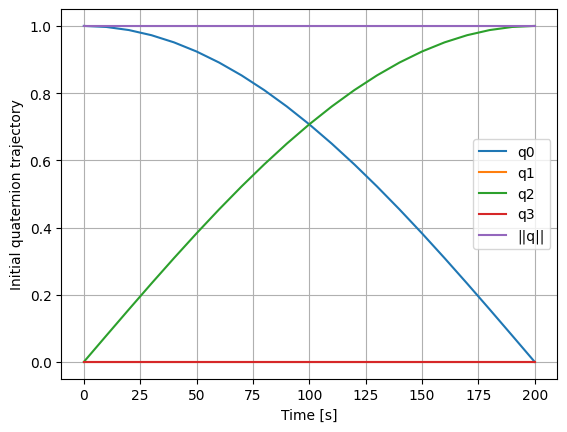

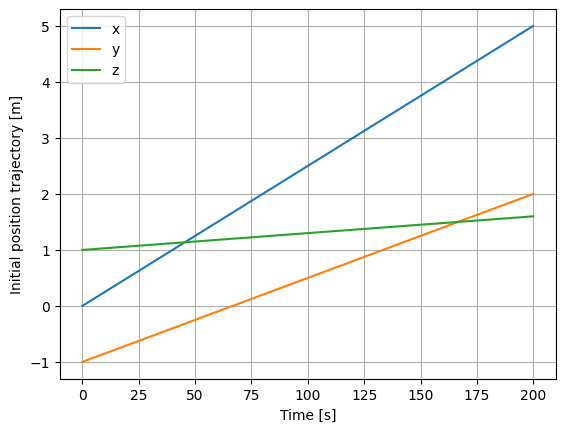

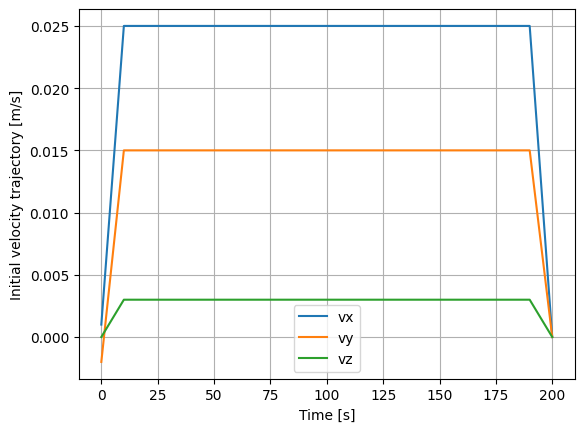

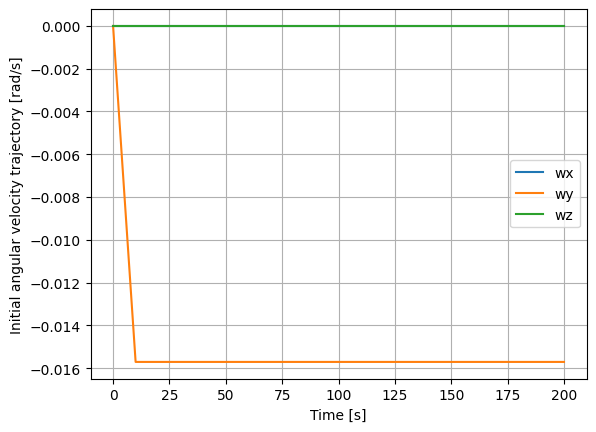

In [40]:
# Plot (scaled initial trajectories)

hu_value=np.copy(ohu_init)
hx_value=np.copy(ohx_init)

plt.figure(1)
plt.plot(np.linspace(0, tf, T+1), hx_value[6,:], label='q0')
plt.plot(np.linspace(0, tf, T+1), hx_value[7,:], label='q1')
plt.plot(np.linspace(0, tf, T+1), hx_value[8,:], label='q2')
plt.plot(np.linspace(0, tf, T+1), hx_value[9,:], label='q3')
plt.plot(np.linspace(0, tf, T+1), np.linalg.norm(hx_value[6:10,:],axis=0), label='||q||')
plt.ylabel('Initial quaternion trajectory')
plt.xlabel('Time [s]')
plt.gca().tick_params(labelsize=10)
plt.legend()
plt.grid(True)

plt.figure(2)
plt.plot(np.linspace(0, tf, T+1), hx_value[0,:], label='x')
plt.plot(np.linspace(0, tf, T+1), hx_value[1,:], label='y')
plt.plot(np.linspace(0, tf, T+1), hx_value[2,:], label='z')

plt.ylabel('Initial position trajectory [m]')
plt.xlabel('Time [s]')
plt.gca().tick_params(labelsize=10)
plt.legend()
plt.grid(True)

plt.figure(3)
plt.plot(np.linspace(0, tf, T+1), hx_value[3,:], label='vx')
plt.plot(np.linspace(0, tf, T+1), hx_value[4,:], label='vy')
plt.plot(np.linspace(0, tf, T+1), hx_value[5,:], label='vz')

plt.ylabel('Initial velocity trajectory [m/s]')
plt.xlabel('Time [s]')
plt.gca().tick_params(labelsize=10)
plt.legend()
plt.grid(True)

plt.figure(4)
plt.plot(np.linspace(0, tf, T+1), hx_value[10,:], label='wx')
plt.plot(np.linspace(0, tf, T+1), hx_value[11,:], label='wy')
plt.plot(np.linspace(0, tf, T+1), hx_value[12,:], label='wz')

plt.ylabel('Initial angular velocity trajectory [rad/s]')
plt.xlabel('Time [s]')
plt.gca().tick_params(labelsize=10)
plt.legend()
plt.grid(True)

CVXpy Optimization problem (DPP compliant for cvxpygen)

In [41]:
def h_lambda_CVXpy_DPP(z):
     return cp.power(cp.pos(z),2)

x = cp.Variable((states_size, T + 1), name='x')
u = cp.Variable((inputs_size, T + 1), name='u')

A_discrete = cp.Parameter((states_size,states_size*T), name='A_discrete')
B_discrete_l = cp.Parameter((states_size,inputs_size*T), name='B_discrete_l')
B_discrete_r = cp.Parameter((states_size,inputs_size*T), name='B_discrete_r')
y_discrete = cp.Parameter((states_size,1*T), name='y_discrete')

if non_convex_inequalities_size>0:
    sqrt_tau_sqrt_lamb_C_discrete = cp.Parameter((non_convex_inequalities_size,states_size*(T+1)), name='sqrt_tau_sqrt_lamb_C_discrete')
    sqrt_tau_sqrt_lamb_z_discrete = cp.Parameter((non_convex_inequalities_size,1*(T+1)), name='sqrt_tau_sqrt_lamb_z_discrete')
    
sqrt_tau = cp.Parameter(name='sqrt_tau')
sqrt_tau_sqrt_lamb = cp.Parameter(name='sqrt_tau_sqrt_lamb')
sqrt_tau_sqrt_lamb_etta = cp.Parameter(name='sqrt_tau_sqrt_lamb_etta')

start_pos = cp.Parameter((states_size, 1), name='start_pos')
end_pos = cp.Parameter((states_size, 1), name='end_pos')

sqrt_tau_sqrt_lamb_ox = cp.Parameter((states_size, T + 1), name='sqrt_tau_sqrt_lamb_ox')

sqrt_tau_sqrt_lamb_S_x_scaling = cp.Parameter((states_size,states_size), name='sqrt_tau_sqrt_lamb_S_x_scaling')
S_u_scaling = cp.Parameter((inputs_size,inputs_size), name='S_u_scaling')

sqrt_tau_sqrt_lamb_c_x_scaling = cp.Parameter((states_size, 1), name='sqrt_tau_sqrt_lamb_c_x_scaling')
c_u_scaling = cp.Parameter((inputs_size, 1), name='c_u_scaling')

sqrt_tau_sqrt_lamb_vel_max= cp.Parameter(name='sqrt_tau_sqrt_lamb_vel_max')
sqrt_tau_sqrt_lamb_omega_max = cp.Parameter(name='sqrt_tau_sqrt_lamb_omega_max')

acc_max = cp.Parameter(name='acc_max')
torq_max = cp.Parameter(name='torq_max')

constraints = [
    x[:, 0] == start_pos[:,0],
    x[:, T] == end_pos[:,0]
]

cost = 0

for k in range(0, T):
    #cost += cp.sum_squares(sqrt_tau*u[0:3,k:k+1])
    cost += (1/3) * (cp.sum_squares(sqrt_tau*u[0:3,k:k+1]) + cp.sum_squares(sqrt_tau*u[0:3,k+1:k+2]) + cp.sum_squares(sqrt_tau*(u[0:3,k:k+1] - u[0:3,k+1:k+2])))
    cost += (1/3) * (cp.sum_squares(sqrt_tau*u[3:6,k:k+1]) + cp.sum_squares(sqrt_tau*u[3:6,k+1:k+2]) + cp.sum_squares(sqrt_tau*(u[3:6,k:k+1] - u[3:6,k+1:k+2])))

for k in range(0, T+1):
    cost += h_lambda_CVXpy_DPP(cp.sum([cp.norm(sqrt_tau_sqrt_lamb*x[:, k]-sqrt_tau_sqrt_lamb_ox[:,k],'inf'),-sqrt_tau_sqrt_lamb_etta])) #g_tr

    if non_convex_inequalities_size>0:
        aux_n_s_vector = sqrt_tau_sqrt_lamb_C_discrete[0:non_convex_inequalities_size,states_size*k:states_size*(k+1)] @ x[0:states_size, k:k+1] + sqrt_tau_sqrt_lamb_z_discrete[0:non_convex_inequalities_size, k:k+1]
        for j in range(0,non_convex_inequalities_size):
            cost += h_lambda_CVXpy_DPP(aux_n_s_vector[j,0]) #sum_n_s

for k in range(0, T+1):
    cost += h_lambda_CVXpy_DPP(cp.norm(sqrt_tau_sqrt_lamb_S_x_scaling[3:6,3:6]@x[3:6,k:k+1]+sqrt_tau_sqrt_lamb_c_x_scaling[3:6,0:1], 2)-sqrt_tau_sqrt_lamb_vel_max) #sum_nw v<=v_max
    cost += h_lambda_CVXpy_DPP(cp.norm(sqrt_tau_sqrt_lamb_S_x_scaling[10:13,10:13]@x[10:13,k:k+1]+sqrt_tau_sqrt_lamb_c_x_scaling[10:13,0:1], 2)-sqrt_tau_sqrt_lamb_omega_max) #sum_nw w<=w_max

for k in range(0, T): # from 0 to T-1
    constraints += [x[0:states_size, k+1:k+2] == A_discrete[0:states_size,states_size*k:states_size*(k+1)] @ x[0:states_size, k:k+1] + B_discrete_l[0:states_size,inputs_size*k:inputs_size*(k+1)] @ u[0:inputs_size, k:k+1]+B_discrete_r[0:states_size,inputs_size*k:inputs_size*(k+1)] @ u[0:inputs_size, k+1:k+2]+y_discrete[0:states_size, k:k+1]]

# Convex constraints (only U, requested by GuSTO)
for k in range(0, T+1): # from 0 to T
    constraints += [cp.norm(S_u_scaling[0:3,0:3]@u[0:3,k:k+1]+c_u_scaling[0:3,0:1], 'inf')<=acc_max]
    constraints += [cp.norm(S_u_scaling[3:6,3:6]@u[3:6,k:k+1]+c_u_scaling[3:6,0:1], 'inf')<=torq_max]

objective = cp.Minimize(cost)
problem = cp.Problem(objective, constraints)

COMPULSORY: The problem needs to be DPP compliant for CVXpygen

In [42]:
print("Is DPP? ", problem.is_dcp(dpp=True))

Is DPP?  True


In [43]:
aux_A_discrete = np.zeros((states_size,states_size*T))
aux_B_discrete_l = np.zeros((states_size,inputs_size*T))
aux_B_discrete_r = np.zeros((states_size,inputs_size*T))
aux_y_discrete = np.zeros((states_size,1*T))

if non_convex_inequalities_size>0:
    aux_C_discrete = np.zeros((non_convex_inequalities_size,states_size*(T+1)))
    aux_z_discrete = np.zeros((non_convex_inequalities_size,1*(T+1)))

In [44]:
def GuSTO_scaling_x(x_no_scaled,inv_S_x_scaling_double,c_x_scaling_double):
    x_scaled = inv_S_x_scaling_double@(x_no_scaled-c_x_scaling_double)
    return x_scaled
    
def GuSTO_scaling_u(u_no_scaled,inv_S_u_scaling_double,c_u_scaling_double):
    u_scaled = inv_S_u_scaling_double@(u_no_scaled-c_u_scaling_double)
    return u_scaled

def GuSTO_inv_scaling_x(x_scaled,S_x_scaling_double,c_x_scaling_double):
    x_inv_scaling = S_x_scaling_double@x_scaled+c_x_scaling_double
    return x_inv_scaling
    
def GuSTO_inv_scaling_u(u_scaled,S_u_scaling_double,c_u_scaling_double):
    u_inv_scaling = S_u_scaling_double@u_scaled+c_u_scaling_double
    return u_inv_scaling

def A_no_discrete_scaled_GuSTO(A_no_discrete_no_scaled, inv_S_x_scaling_double,S_x_scaling_double):

    A_numeric = inv_S_x_scaling_double@A_no_discrete_no_scaled@S_x_scaling_double

    return A_numeric

def B_no_discrete_scaled_GuSTO(B_no_discrete_no_scaled, inv_S_x_scaling_double, S_u_scaling_double):

    B_numeric = inv_S_x_scaling_double@B_no_discrete_no_scaled@S_u_scaling_double

    return B_numeric

def y_no_discrete_scaled_GuSTO(A_no_discrete_no_scaled,
                              B_no_discrete_no_scaled,
                              y_no_discrete_no_scaled,
                              inv_S_x_scaling_double, c_x_scaling_double, c_u_scaling_double):

    y_numeric = inv_S_x_scaling_double@A_no_discrete_no_scaled@c_x_scaling_double
    y_numeric = y_numeric+inv_S_x_scaling_double@B_no_discrete_no_scaled@c_u_scaling_double
    y_numeric = y_numeric+inv_S_x_scaling_double@y_no_discrete_no_scaled

    return y_numeric
    
import numpy as np

def A_Bl_Br_y_discrete_scaled(
        ohx, ohu, t0, dynamic_parameters_double, tau_double,
        S_x_scaling_double, inv_S_x_scaling_double, c_x_scaling_double,
        S_u_scaling_double, inv_S_u_scaling_double, c_u_scaling_double,
        size_N):

    n = len(ohx)
    m = len(ohu)

    # Initial conditions for integration over the interval [t0, t0 + tau]
    Phi = np.eye(n)            # State transition matrix
    Gm  = np.zeros((n, m))     # FOH left input matrix B_k^-
    Gp  = np.zeros((n, m))     # FOH right input matrix B_k^+
    z   = np.zeros((n, 1))     # Affine term

    dt = tau_double / (size_N - 1)
    t  = t0
    tf = t0 + tau_double

    # FOH lambda functions (linear interpolation weights)
    # lam_m(t0) = 1, lam_m(tf) = 0
    # lam_p(t0) = 0, lam_p(tf) = 1
    def lambdas(ti):
        lam_m = (tf - ti) / tau_double
        lam_p = (ti - t0) / tau_double
        return lam_m, lam_p

    def get_scaled_dynamics(t_eval):
        # 1. Obtain continuous-time, unscaled LTV matrices (time-dependent)
        A_no = A_no_discrete_no_scaled_GuSTO(ohx, ohu, t_eval, dynamic_parameters_double)
        B_no = B_no_discrete_no_scaled_GuSTO(ohx, ohu, t_eval, dynamic_parameters_double)
        y_no = y_no_discrete_no_scaled_GuSTO(ohx, ohu, t_eval, dynamic_parameters_double)

        # 2. Apply state and input scaling
        A = A_no_discrete_scaled_GuSTO(A_no, inv_S_x_scaling_double, S_x_scaling_double)
        B = B_no_discrete_scaled_GuSTO(B_no, inv_S_x_scaling_double, S_u_scaling_double)
        y = y_no_discrete_scaled_GuSTO(A_no, B_no, y_no, inv_S_x_scaling_double, c_x_scaling_double, c_u_scaling_double)
        return A, B, y

    for i in range(size_N - 1):

        # ===== k1 (beginning of sub-step) =====
        lam_m1, lam_p1 = lambdas(t)
        A1, B1, y1 = get_scaled_dynamics(t)

        k1_Phi = A1 @ Phi
        k1_Gm  = A1 @ Gm + B1 * lam_m1
        k1_Gp  = A1 @ Gp + B1 * lam_p1
        k1_z   = A1 @ z  + y1

        # ===== k2 (midpoint) =====
        t2 = t + 0.5 * dt
        lam_m2, lam_p2 = lambdas(t2)
        A2, B2, y2 = get_scaled_dynamics(t2)

        Phi2 = Phi + 0.5 * dt * k1_Phi
        Gm2  = Gm  + 0.5 * dt * k1_Gm
        Gp2  = Gp  + 0.5 * dt * k1_Gp
        z2   = z   + 0.5 * dt * k1_z

        k2_Phi = A2 @ Phi2
        k2_Gm  = A2 @ Gm2 + B2 * lam_m2
        k2_Gp  = A2 @ Gp2 + B2 * lam_p2
        k2_z   = A2 @ z2  + y2

        # ===== k3 (midpoint using k2 state) =====
        # For LTV systems, A, B, y are evaluated at the same midpoint time
        Phi3 = Phi + 0.5 * dt * k2_Phi
        Gm3  = Gm  + 0.5 * dt * k2_Gm
        Gp3  = Gp  + 0.5 * dt * k2_Gp
        z3   = z   + 0.5 * dt * k2_z

        k3_Phi = A2 @ Phi3
        k3_Gm  = A2 @ Gm3 + B2 * lam_m2
        k3_Gp  = A2 @ Gp3 + B2 * lam_p2
        k3_z   = A2 @ z3  + y2

        # ===== k4 (end of sub-step) =====
        t4 = t + dt
        lam_m4, lam_p4 = lambdas(t4)
        A4, B4, y4 = get_scaled_dynamics(t4)

        Phi4 = Phi + dt * k3_Phi
        Gm4  = Gm  + dt * k3_Gm
        Gp4  = Gp  + dt * k3_Gp
        z4   = z   + dt * k3_z

        k4_Phi = A4 @ Phi4
        k4_Gm  = A4 @ Gm4 + B4 * lam_m4
        k4_Gp  = A4 @ Gp4 + B4 * lam_p4
        k4_z   = A4 @ z4  + y4

        # ===== RK4 update =====
        Phi += (dt / 6) * (k1_Phi + 2*k2_Phi + 2*k3_Phi + k4_Phi)
        Gm  += (dt / 6) * (k1_Gm  + 2*k2_Gm  + 2*k3_Gm  + k4_Gm)
        Gp  += (dt / 6) * (k1_Gp  + 2*k2_Gp  + 2*k3_Gp  + k4_Gp)
        z   += (dt / 6) * (k1_z   + 2*k2_z   + 2*k3_z   + k4_z)

        t += dt

    # Final results:
    # Since we integrate the full ODE
    #   dot(G) = A(t) G + B(t) lambda(t),
    # the final values are the discrete-time FOH matrices.
    return Phi, Gm, Gp, z

def C_no_discrete_scaled_GuSTO(C_no_discrete_no_scaled, S_x_scaling_double):

    C_numeric = C_no_discrete_no_scaled@S_x_scaling_double

    return C_numeric

def z_no_discrete_scaled_GuSTO(C_no_discrete_no_scaled,
                              z_no_discrete_no_scaled,
                              c_x_scaling_double, c_u_scaling_double):

    z_numeric = C_no_discrete_no_scaled@c_x_scaling_double
    z_numeric = z_numeric+z_no_discrete_no_scaled

    return z_numeric

def C_z_discrete_scaled(ohx, ohu, t0, dynamic_parameters,
                           S_x_scaling_double, c_x_scaling_double,
                           S_u_scaling_double, c_u_scaling_double):
    

    C_no_discrete_no_scaled = C_no_discrete_no_scaled_GuSTO(ohx, t0, dynamic_parameters)
    C_no_discrete_scaled = C_no_discrete_scaled_GuSTO(C_no_discrete_no_scaled, S_x_scaling_double)

    z_no_discrete_no_scaled = z_no_discrete_no_scaled_GuSTO(ohx, t0, dynamic_parameters)
    z_no_discrete_scaled = z_no_discrete_scaled_GuSTO(C_no_discrete_no_scaled,
                                                     z_no_discrete_no_scaled,
                                                     c_x_scaling_double, c_u_scaling_double)
    
    #Discretization no needed, bypass
    return C_no_discrete_scaled, z_no_discrete_scaled

def u_foh(uk, ukp1, dt_aux):
    return (1 - dt_aux) * uk + dt_aux * ukp1

def f_rk4_step_foh(xk, uk, ukp1, t, dt, dynamic_parameters,
                   S_x_scaling_double, c_x_scaling_double,
                   S_u_scaling_double, c_u_scaling_double):

    x = GuSTO_inv_scaling_x(xk, S_x_scaling_double, c_x_scaling_double)
    uk = GuSTO_inv_scaling_u(uk, S_u_scaling_double, c_u_scaling_double)
    ukp1 = GuSTO_inv_scaling_u(ukp1, S_u_scaling_double, c_u_scaling_double)

    k1 = f_GuSTO(x, u_foh(uk, ukp1, 0.0), t, dynamic_parameters)
    k2 = f_GuSTO(x + 0.5*dt*k1, u_foh(uk, ukp1, 0.5), t + 0.5*dt, dynamic_parameters)
    k3 = f_GuSTO(x + 0.5*dt*k2, u_foh(uk, ukp1, 0.5), t + 0.5*dt, dynamic_parameters)
    k4 = f_GuSTO(x + dt*k3, u_foh(uk, ukp1, 1.0), t + dt, dynamic_parameters)

    return x + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)

In [45]:
print(all([True,True,True,True]))

True


Modify the SCVx cost function according to user requirements:

In [46]:
def h_lambda(z,lamb_double):
  if z>=0:
    return lamb_double*z**2
  if z<0:
    return 0
def lamb_update(lamb_double,x,T,dynamic_parameters_double):
    hx=np.zeros((states_size,T+1))
    g_GuSTO_bool = [True] * non_convex_inequalities_size

    wmax_bool=True
    vmax_bool=True
    
    for k in range(0, T+1):
        hx[:,k:k+1] = GuSTO_inv_scaling_x(x[:,k:k+1],S_x_scaling_double,c_x_scaling_double)

    if non_convex_inequalities_size>0:
        for k in range(0, T+1):               
            g_double = g_GuSTO(hx[:,k:k+1], k/T*tf, dynamic_parameters_double)

            for j in range(0,non_convex_inequalities_size):
                g_GuSTO_bool[j]=(g_double[j,0]<=0) and g_GuSTO_bool[j]
    
    for k in range(0,T+1):
        vmax_bool=(np.linalg.norm(hx[3:6,k:k+1])<=vel_max_double) and vmax_bool #v<=vmax
        wmax_bool=(np.linalg.norm(hx[10:13,k:k+1])<=omega_max_double) and wmax_bool #w<=wmax

        if not all(g_GuSTO_bool) or not(wmax_bool) or not(vmax_bool):
            print(g_GuSTO_bool)
            print(wmax_bool)
            print(vmax_bool)
            break;
    if all(g_GuSTO_bool) and vmax_bool and wmax_bool:
        print("Keel lambda")
        return lambda_0
    else:
        print("Lambda fail")
        return gamma_fail*lamb_double
    
def sum_x_star_and_Theta_star(x,u,dynamic_parameters_double,T):
    dx_k_star=np.zeros((states_size,1))
    
    sum_x=0
    Theta_sum=0

    hx=np.zeros((states_size,T+1))
    hu=np.zeros((inputs_size,T+1))

    for k in range(0, T+1):
        hx[:,k:k+1] = GuSTO_inv_scaling_x(x[:,k:k+1],S_x_scaling_double,c_x_scaling_double)
        hu[:,k:k+1] = GuSTO_inv_scaling_x(u[:,k:k+1],S_u_scaling_double,c_u_scaling_double)

    for k in range(0,T):
        
        aux_A_no_discrete_no_scaled_GuSTO = A_no_discrete_no_scaled_GuSTO(hx[0:states_size,k:k+1], hu[0:inputs_size,k:k+1], k/T*tf, dynamic_parameters_double)
        aux_B_no_discrete_no_scaled_GuSTO = B_no_discrete_no_scaled_GuSTO(hx[0:states_size,k:k+1], hu[0:inputs_size,k:k+1], k/T*tf, dynamic_parameters_double)
        aux_y_no_discrete_no_scaled_GuSTO = y_no_discrete_no_scaled_GuSTO(hx[0:states_size,k:k+1], hu[0:inputs_size,k:k+1], k/T*tf, dynamic_parameters_double)
        
        dx_k_star=aux_A_no_discrete_no_scaled_GuSTO@hx[0:states_size, k:k+1]+aux_B_no_discrete_no_scaled_GuSTO@hu[0:inputs_size, k:k+1]+aux_y_no_discrete_no_scaled_GuSTO

        sum_x+=tau_double*np.linalg.norm(dx_k_star,ord=2)

        Theta_sum+=tau_double*np.linalg.norm(f_GuSTO(hx[0:states_size,k:k+1], hu[0:inputs_size,k:k+1], k/T*tf, dynamic_parameters_double)-dx_k_star,ord=2)

    return [sum_x,Theta_sum]

def J_lamb_GuSTO(x,ox,u,etta_double,lamb_double,dynamic_parameters_double,T):
    hx=np.zeros((states_size,T+1))
    
    for k in range(0, T+1):
        hx[0:states_size,k:k+1] = GuSTO_inv_scaling_x(x[0:states_size,k:k+1],S_x_scaling_double,c_x_scaling_double)
        
    cost1 = 0
    cost2 = 0
    cost3 = 0

    for k in range(0, T): # from 0 to T-1
        cost1 += (tau_double/3) * (np.linalg.norm(u[0:3,k:k+1], ord=2)**2 + np.linalg.norm(u[0:3,k+1:k+2], ord=2)**2 + np.linalg.norm((u[0:3,k:k+1] - u[0:3,k+1:k+2]), ord=2)**2)
        cost1 += (tau_double/3) * (np.linalg.norm(u[3:6,k:k+1], ord=2)**2 + np.linalg.norm(u[3:6,k+1:k+2], ord=2)**2 + np.linalg.norm((u[3:6,k:k+1] - u[3:6,k+1:k+2]), ord=2)**2)

    for k in range(0, T+1):
        cost2 += tau_double*h_lambda(np.linalg.norm(x[0:states_size,k:k+1]-ox[:,k:k+1], ord=np.inf)-etta_double,lamb_double)
    print("cost2 (x-ox): ",cost2)
    if non_convex_inequalities_size>0:
        for k in range(0, T+1):             
            g_double = g_GuSTO(hx[0:states_size,k:k+1], k/T*tf, dynamic_parameters_double)

            for j in range(0,non_convex_inequalities_size):
                cost2 += tau_double*h_lambda(g_double[j,0],lamb_double)
    
    for k in range(0, T+1):
        cost3 += tau_double*h_lambda(np.linalg.norm(hx[3:6,k:k+1], ord=2)-vel_max_double,lamb_double) #sum_nw v<=v_max
        cost3 += tau_double*h_lambda(np.linalg.norm(hx[10:13,k:k+1], ord=2)-omega_max_double,lamb_double) #sum_nw w<=w_max
    
    print("cost1: ",cost1)
    print("cost2: ",cost2)
    print("cost3: ",cost3)

    return cost1+cost2+cost3

In [47]:
1000*0.05*np.pi*(0.04**2)

0.25132741228718347

In [48]:
ox = np.zeros((states_size,T+1))
ou = np.zeros((inputs_size,T+1))

inv_S_x_scaling_double = np.linalg.inv(S_x_scaling_double)
inv_S_u_scaling_double = np.linalg.inv(S_u_scaling_double)

ohx = np.copy(ohx_init) 
ohu = np.copy(ohu_init)

for t in range(0, T + 1):
    ox[0:states_size,t:t+1] = GuSTO_scaling_x(ohx[0:states_size,t:t+1],inv_S_x_scaling_double,c_x_scaling_double)

for t in range(0, T + 1):
    ou[0:inputs_size,t:t+1] = GuSTO_scaling_u(ohu[0:inputs_size,t:t+1],inv_S_u_scaling_double,c_u_scaling_double)


sqrt_tau_sqrt_lamb_ox.value=(tau_double)**0.5*(lamb_double)**0.5*ox #trajectory initialization (already scaled)

sqrt_tau.value = (tau_double)**0.5

sqrt_tau_sqrt_lamb.value = (tau_double)**0.5*(lamb_double)**0.5
sqrt_tau_sqrt_lamb_etta.value = (tau_double)**0.5*(lamb_double)**0.5*etta_double

sqrt_tau_sqrt_lamb_S_x_scaling.value = (tau_double)**0.5*(lamb_double)**0.5*S_x_scaling_double
S_u_scaling.value = np.copy(S_u_scaling_double)

sqrt_tau_sqrt_lamb_c_x_scaling.value = (tau_double)**0.5*(lamb_double)**0.5*c_x_scaling_double
c_u_scaling.value = np.copy(c_u_scaling_double)

sqrt_tau_sqrt_lamb_vel_max.value = (tau_double)**0.5*(lamb_double)**0.5*vel_max_double
sqrt_tau_sqrt_lamb_omega_max.value = (tau_double)**0.5*(lamb_double)**0.5*omega_max_double

acc_max.value = acc_max_double
torq_max.value = torq_max_double

start_pos.value = GuSTO_scaling_x(start_pos_double,inv_S_x_scaling_double,c_x_scaling_double)
end_pos.value = GuSTO_scaling_x(end_pos_double,inv_S_x_scaling_double,c_x_scaling_double)

t0 = time.time()

i=1
no_first_iterations = False
rho_i = "None"

for COGU_iter in range(COGU_max_iter):

    for t in range(0, T + 1):
        ohx[0:states_size,t:t+1] = GuSTO_inv_scaling_x(ox[0:states_size,t:t+1],S_x_scaling_double,c_x_scaling_double)

    for t in range(0, T + 1):
        ohu[0:inputs_size,t:t+1] = GuSTO_inv_scaling_u(ou[0:inputs_size,t:t+1],S_u_scaling_double,c_u_scaling_double)

    t0aux = time.time()
    for k in range(0, T):
        aux_aux_A_discrete, aux_aux_B_discrete_l, aux_aux_B_discrete_r, aux_aux_y_discrete = A_Bl_Br_y_discrete_scaled(ohx[0:states_size,k:k+1], ohu[0:inputs_size,k:k+1], k/T*tf, dynamic_parameters_double, tau_double,
                          S_x_scaling_double, inv_S_x_scaling_double, c_x_scaling_double,
                          S_u_scaling_double, inv_S_u_scaling_double, c_u_scaling_double, size_N)

        aux_A_discrete[0:states_size,states_size*k:states_size*(k+1)] = np.copy(aux_aux_A_discrete)
        
        aux_B_discrete_l[0:states_size,inputs_size*k:inputs_size*(k+1)] = np.copy(aux_aux_B_discrete_l)
        
        aux_B_discrete_r[0:states_size,inputs_size*k:inputs_size*(k+1)] = np.copy(aux_aux_B_discrete_r)

        aux_y_discrete[0:states_size,k:k+1] = np.copy(aux_aux_y_discrete)
    
    if non_convex_inequalities_size>0:
      for k in range(0, T+1):
          aux_aux_C_discrete, aux_aux_z_discrete = C_z_discrete_scaled(ohx[0:states_size,k:k+1], ohu[0:inputs_size,k:k+1], k/T*tf, dynamic_parameters_double,
                  S_x_scaling_double, c_x_scaling_double,
                  S_u_scaling_double, c_u_scaling_double)
          
          aux_C_discrete[0:non_convex_inequalities_size,states_size*k:states_size*(k+1)] = np.copy(aux_aux_C_discrete)
          
          aux_z_discrete[0:non_convex_inequalities_size,k:k+1] = np.copy(aux_aux_z_discrete)

    t1aux = time.time()
    print("Discretization time [ms]: ",(t1aux-t0aux)*1000)

    A_discrete.value = np.copy(aux_A_discrete)
    B_discrete_l.value = np.copy(aux_B_discrete_l)
    B_discrete_r.value = np.copy(aux_B_discrete_r)
    y_discrete.value = np.copy(aux_y_discrete)

    if non_convex_inequalities_size>0:
      sqrt_tau_sqrt_lamb_C_discrete.value = (tau_double)**0.5*(lamb_double)**0.5*aux_C_discrete
      sqrt_tau_sqrt_lamb_z_discrete.value = (tau_double)**0.5*(lamb_double)**0.5*aux_z_discrete

    t0aux = time.time()
    val=problem.solve(solver='ECOS',ignore_dpp=True) #IF YOU USE CVXPYGEN: ignore_dpp=False
    t1aux = time.time()

    print("Solver time [ms]: ",(t1aux-t0aux)*1000)

    L_lambda=val
    x_opt = np.copy(x.value)
    u_opt = np.copy(u.value)

    trapz_Deltau=0
    for k in range(0,T):
        trapz_Deltau+=tau_double*np.linalg.norm(u_opt[:, k:k+1]-ou[:, k:k+1], ord=np.inf)

    J_lamb_opt=J_lamb_GuSTO(x_opt,ox,u_opt,etta_double,lamb_double,dynamic_parameters_double,T)
    J_GuSTO_stop=np.abs(J_lamb_old-J_lamb_opt)/np.abs(J_lamb_old)
    
    flag_case4=True
    for k in range(0,T+1):
        if np.linalg.norm(x_opt[:, k:k+1]-ox[:, k:k+1], ord=np.inf)>etta_double:
            print("Case 4")
            etta_double=etta_double
            ox=ox
            ou=ou
            lamb_double=gamma_fail*lamb_double
            flag_case4=False
            J_lamb_old = J_lamb_old
            break;

    if flag_case4:
      sum_x_star, Theta_star = sum_x_star_and_Theta_star(x_opt,u_opt,dynamic_parameters_double,T)
      rho_i=(abs(J_lamb_opt-L_lambda)+Theta_star)/(abs(L_lambda)+sum_x_star)
      print("J_lamb_GuSTO: ",J_lamb_opt," L_lambda: ",L_lambda," rho:",rho_i)
      if rho_i<rho0:
          etta_double=min([etta1,beta_gr*etta_double])
          ox = np.copy(x_opt)
          ou = np.copy(u_opt)
          lamb_double=lamb_update(lamb_double,x_opt,T,dynamic_parameters_double)
          J_lamb_old = J_lamb_opt
          print("Case 1")
      if rho_i>=rho0 and rho_i<rho1:
          etta_double=etta_double
          ox = np.copy(x_opt)
          ou = np.copy(u_opt)
          lamb_double=lamb_update(lamb_double,x_opt,T,dynamic_parameters_double)
          J_lamb_old = J_lamb_opt
          print("Case 2")
      if rho_i>=rho1:
          etta_double=max([etta0,etta_double/beta_sh])
          ox=np.copy(ox)
          ou=np.copy(ou)
          lamb_double=lamb_double
          J_lamb_old = J_lamb_old
          print("Case 3")

    sqrt_tau_sqrt_lamb_ox.value=(tau_double)**0.5*(lamb_double)**0.5*ox #trajectory initialization (already scaled)

    sqrt_tau_sqrt_lamb.value = (tau_double)**0.5*(lamb_double)**0.5
    sqrt_tau_sqrt_lamb_etta.value = (tau_double)**0.5*(lamb_double)**0.5*etta_double

    sqrt_tau_sqrt_lamb_S_x_scaling.value = (tau_double)**0.5*(lamb_double)**0.5*S_x_scaling_double
    S_u_scaling.value = np.copy(S_u_scaling_double)

    sqrt_tau_sqrt_lamb_c_x_scaling.value = (tau_double)**0.5*(lamb_double)**0.5*c_x_scaling_double
    c_u_scaling.value = np.copy(c_u_scaling_double)

    sqrt_tau_sqrt_lamb_vel_max.value = (tau_double)**0.5*(lamb_double)**0.5*vel_max_double
    sqrt_tau_sqrt_lamb_omega_max.value = (tau_double)**0.5*(lamb_double)**0.5*omega_max_double

    print(" Iteration number: ",i," L_lambda: ", val," Etta: ",etta_double,"Lambda: ",lamb_double,"Trap_Du: ",trapz_Deltau, "J_stop: ",J_GuSTO_stop, "Theta*: ", Theta_star)
    i=i+1

    if COGU_iter>2 and (lamb_double>lambda_max or (trapz_Deltau<epsilon) or J_GuSTO_stop<epsilon_r):
        u_global = np.copy(ou)
        x_global = np.copy(ox)
        print("lamb_double>lambda_max: ", lamb_double>lambda_max)
        print("trapz_Deltau<e_tol: ", trapz_Deltau<epsilon)
        print("J_GuSTO_stop<epsilon_r: ", J_GuSTO_stop<epsilon_r)
        trapz_Deltau=100000 #Big initial value
        J_GuSTO_stop=100000 #Big initial value
        break;

t1 = time.time()
print('\nCVXPY\nSolve time: %.3f ms' % (1000 * (t1 - t0)))

Discretization time [ms]:  32.32383728027344
Solver time [ms]:  701.9009590148926
cost2 (x-ox):  0.0
cost1:  204.66510707398785
cost2:  0.0
cost3:  0.0
J_lamb_GuSTO:  204.66510707398785  L_lambda:  204.66510764615347  rho: 2.7050258757807953e-09
Keel lambda
Case 1
 Iteration number:  1  L_lambda:  204.66510764615347  Etta:  2 Lambda:  1000000 Trap_Du:  25.485772308660685 J_stop:  203.66510707398785 Theta*:  1.0971604764688851e-16
Discretization time [ms]:  30.67946434020996
Solver time [ms]:  634.2260837554932
cost2 (x-ox):  0.0
cost1:  204.79082461196467
cost2:  0.0
cost3:  0.0021962903233195314
J_lamb_GuSTO:  204.793020902288  L_lambda:  204.79302096996213  rho: 3.201306992772059e-10
[True, True, True]
False
True
Lambda fail
Case 1
 Iteration number:  2  L_lambda:  204.79302096996213  Etta:  4 Lambda:  5000000 Trap_Du:  18.47117965703014 J_stop:  0.0006249908942900344 Theta*:  2.253016962386417e-16
Discretization time [ms]:  31.804323196411133
Solver time [ms]:  624.6693134307861
cos

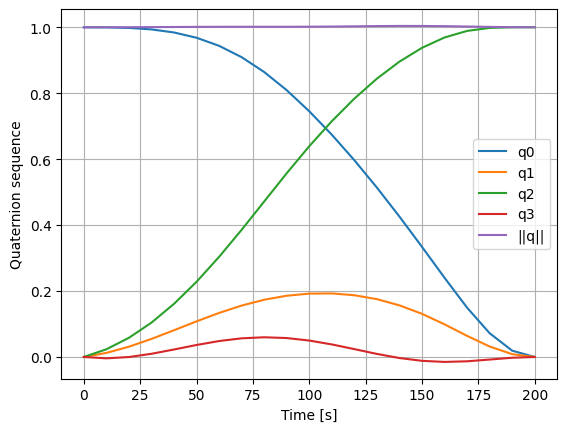

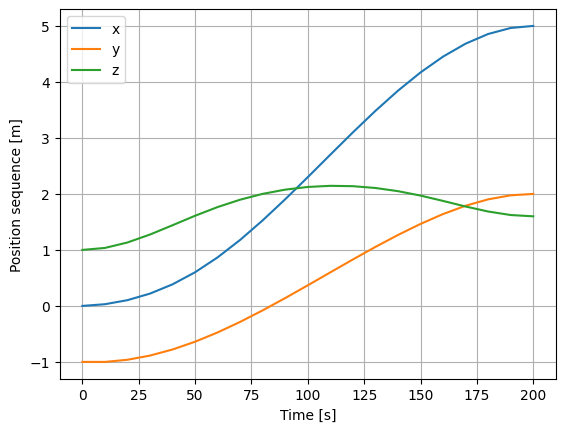

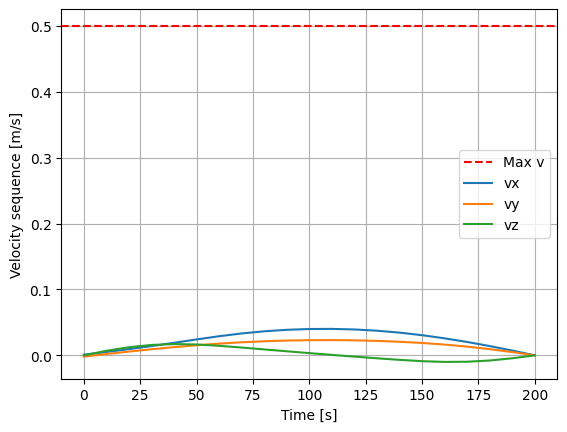

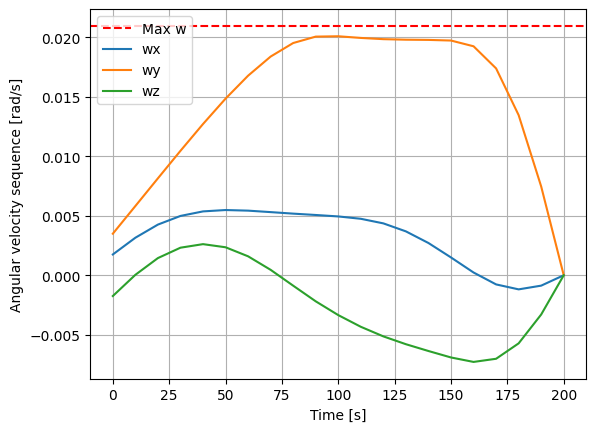

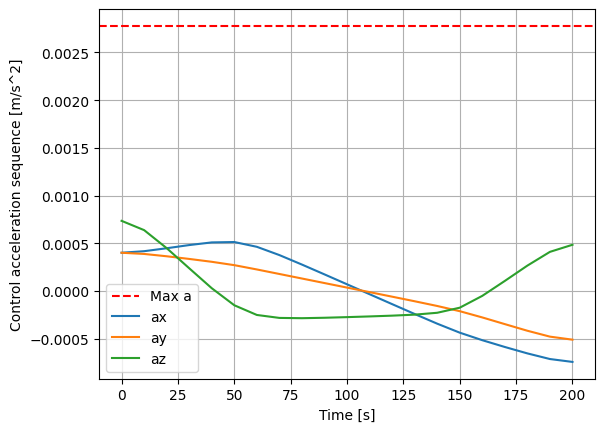

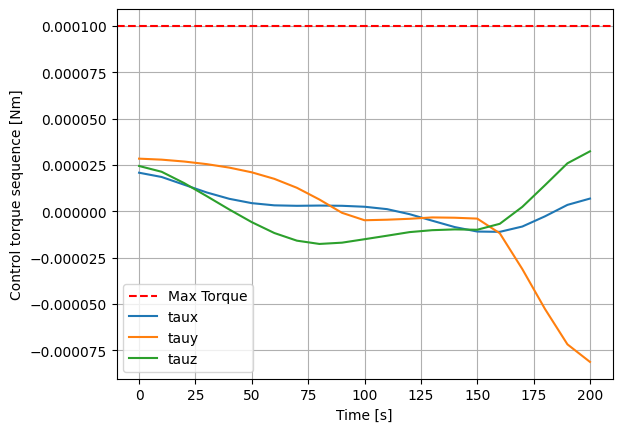

In [49]:
# Plot (scaled initial trajectories)
def global_inv_scaling(x,S,c,T):
    for i in range(0,T,1):
        x[:,i:i+1]=S@x[:,i:i+1]+c
    return x

#Uncomment if there is no optimal solution (or keyboard interruption)

#x_value=global_inv_scaling(np.copy(ox),S_x_scaling_double,c_x_scaling_double,T+1)
#u_value=global_inv_scaling(np.copy(ou),S_u_scaling_double,c_u_scaling_double,T)

x_value=global_inv_scaling(np.copy(ox),S_x_scaling_double,c_x_scaling_double,T+1)
u_value=global_inv_scaling(np.copy(ou),S_u_scaling_double,c_u_scaling_double,T+1)

plt.figure(1)
plt.plot(np.linspace(0, tf, T+1), x_value[6,:], label='q0')
plt.plot(np.linspace(0, tf, T+1), x_value[7,:], label='q1')
plt.plot(np.linspace(0, tf, T+1), x_value[8,:], label='q2')
plt.plot(np.linspace(0, tf, T+1), x_value[9,:], label='q3')
plt.plot(np.linspace(0, tf, T+1), np.linalg.norm(x_value[6:10,:],axis=0), label='||q||')
plt.ylabel('Quaternion sequence')
plt.xlabel('Time [s]')
plt.gca().tick_params(labelsize=10)
plt.legend()
plt.grid(True)

plt.figure(2)
plt.plot(np.linspace(0, tf, T+1), x_value[0,:], label='x')
plt.plot(np.linspace(0, tf, T+1), x_value[1,:], label='y')
plt.plot(np.linspace(0, tf, T+1), x_value[2,:], label='z')

plt.ylabel('Position sequence [m]')
plt.xlabel('Time [s]')
plt.gca().tick_params(labelsize=10)
plt.legend()
plt.grid(True)

plt.figure(3)
plt.axhline(y=vel_max_double, color='r', linestyle='--', label='Max v')
plt.plot(np.linspace(0, tf, T+1), x_value[3,:], label='vx')
plt.plot(np.linspace(0, tf, T+1), x_value[4,:], label='vy')
plt.plot(np.linspace(0, tf, T+1), x_value[5,:], label='vz')

plt.ylabel('Velocity sequence [m/s]')
plt.xlabel('Time [s]')
plt.gca().tick_params(labelsize=10)
plt.legend()
plt.grid(True)


plt.figure(4)
plt.axhline(y=omega_max_double, color='r', linestyle='--', label='Max w')
plt.plot(np.linspace(0, tf, T+1), x_value[10,:], label='wx')
plt.plot(np.linspace(0, tf, T+1), x_value[11,:], label='wy')
plt.plot(np.linspace(0, tf, T+1), x_value[12,:], label='wz')

plt.ylabel('Angular velocity sequence [rad/s]')
plt.xlabel('Time [s]')
plt.gca().tick_params(labelsize=10)
plt.legend()
plt.grid(True)

plt.figure(5)
plt.axhline(y=acc_max_double, color='r', linestyle='--', label='Max a')
plt.plot(np.linspace(0, tf, T+1), u_value[0,:], label='ax')
plt.plot(np.linspace(0, tf, T+1), u_value[1,:], label='ay')
plt.plot(np.linspace(0, tf, T+1), u_value[2,:], label='az')

plt.ylabel('Control acceleration sequence [m/s^2]')
plt.xlabel('Time [s]')
plt.gca().tick_params(labelsize=10)
plt.legend()
plt.grid(True)

plt.figure(6)
plt.axhline(y=torq_max_double, color='r', linestyle='--', label='Max Torque')
plt.plot(np.linspace(0, tf, T+1), u_value[3,:], label='taux')
plt.plot(np.linspace(0, tf, T+1), u_value[4,:], label='tauy')
plt.plot(np.linspace(0, tf, T+1), u_value[5,:], label='tauz')

plt.ylabel('Control torque sequence [Nm]')
plt.xlabel('Time [s]')
plt.gca().tick_params(labelsize=10)
plt.legend()
plt.grid(True)

In [20]:
def create_cube(center, size, quaternion):
    """Creates a rotated cube using a quaternion."""
    half = size / 2.0
    vertices = np.array([  # Cube vertices
        [-half, -half, -half], [half, -half, -half], [half, half, -half], [-half, half, -half],
        [-half, -half, half], [half, -half, half], [half, half, half], [-half, half, half]
    ])

    # Apply rotation using quaternion
    r = R.from_quat(quaternion)
    rotated_vertices = r.apply(vertices) + center

    # Cube faces (each face as a set of 4 vertices)
    faces = [
        [0, 1, 2, 3], [4, 5, 6, 7], [0, 1, 5, 4],
        [2, 3, 7, 6], [0, 3, 7, 4], [1, 2, 6, 5]
    ]

    # Define mesh faces for the cube
    i_faces = [face[0] for face in faces]
    j_faces = [face[1] for face in faces]
    k_faces = [face[2] for face in faces]
    i_faces += [face[0] for face in faces]
    j_faces += [face[2] for face in faces]
    k_faces += [face[3] for face in faces]

    # Mesh3d for the cube (white cube)
    cube = go.Mesh3d(
        x=rotated_vertices[:, 0], y=rotated_vertices[:, 1], z=rotated_vertices[:, 2],
        i=i_faces, j=j_faces, k=k_faces, opacity=1.0, color='white'
    )

    # Create "eyes" (small blue circles) on the cube's faces
    eye_radius = 0.1
    eye_positions = [
        [half,0.13,0], [half,-0.13,0]
    ]

    # Apply rotation to eye positions
    rotated_eye_positions = r.apply(eye_positions) + center

    eye_spheres = []
    for pos in rotated_eye_positions:
        u, v = np.mgrid[0:2*np.pi:10j, 0:np.pi:5j]
        x_eye = eye_radius * np.cos(u) * np.sin(v) + pos[0]
        y_eye = eye_radius * np.sin(u) * np.sin(v) + pos[1]
        z_eye = eye_radius * np.cos(v) + pos[2]

        # Crear una matriz de color uniforme (por ejemplo, azul con un solo valor)
        color_value = np.full_like(x_eye, 0.5)  # 0.5 es un tono de azul en la escala

        eye_spheres.append(go.Surface(
            x=x_eye, y=y_eye, z=z_eye, surfacecolor=color_value,
            colorscale=[[0, 'deepskyblue'], [1, 'deepskyblue']], opacity=1.0, showscale=False
        ))

    return cube, eye_spheres

def create_spheres(spheres):
    """Creates spheres as surfaces."""
    sphere_traces = []
    for sphere in spheres:
        h, rc = sphere['h'], sphere['rc']
        u, v = np.mgrid[0:2*np.pi:16j, 0:np.pi:8j]
        x_sphere = rc * np.cos(u) * np.sin(v) + h[0]
        y_sphere = rc * np.sin(u) * np.sin(v) + h[1]
        z_sphere = rc * np.cos(v) + h[2]
        sphere_traces.append(go.Surface(
            x=x_sphere, y=y_sphere, z=z_sphere, colorscale='Reds', opacity=0.3, showscale=False
        ))
    return sphere_traces

def plot_3d_trajectory_with_cube(x_value, spheres):
    quaternions = x_value[6:10, :]
    x_traj, y_traj, z_traj = x_value[0, :], x_value[1, :], x_value[2, :]

    trace_trajectory = go.Scatter3d(x=x_traj, y=y_traj, z=z_traj, mode='lines',
                                    line=dict(color='blue', width=2))

    # Set axis limits with uniform scaling
    padding = 0.5
    max_range = max(max(x_traj) - min(x_traj), max(y_traj) - min(y_traj), max(z_traj) - min(z_traj)) / 2
    mid_x, mid_y, mid_z = (max(x_traj) + min(x_traj)) / 2, (max(y_traj) + min(y_traj)) / 2, (max(z_traj) + min(z_traj)) / 2
    x_range = [mid_x - max_range - padding, mid_x + max_range + padding]
    y_range = [mid_y - max_range - padding, mid_y + max_range + padding]
    z_range = [mid_z - max_range - padding, mid_z + max_range + padding]

    # Initial cube (white with blue eyes)
    cube, eye_spheres = create_cube([x_traj[0], y_traj[0], z_traj[0]], 0.5, quaternions[:, 0])

    # Initial spheres
    sphere_traces = create_spheres(spheres)

    # Animation frames
    frames = [
        go.Frame(data=[
            go.Scatter3d(x=x_traj, y=y_traj, z=z_traj, mode='lines',
                         marker=dict(size=2, color='blue')),
            create_cube([x_traj[k], y_traj[k], z_traj[k]], 0.5, quaternions[:, k])[0],
        ] + create_spheres(spheres) + create_cube([x_traj[k], y_traj[k], z_traj[k]], 0.5, quaternions[:, k])[1])
        for k in range(len(x_traj))
    ]

    layout = go.Layout(
        title='Astrobee guidance COGU (SCVx, ECOS)',
        scene=dict(
            xaxis_title='x', yaxis_title='y', zaxis_title='z',
            xaxis=dict(range=x_range, autorange=False),
            yaxis=dict(range=y_range, autorange=False),
            zaxis=dict(range=z_range, autorange=False),
            aspectmode='cube',  # Ensures correct proportions
            camera=dict(eye=dict(x=1.5, y=1.5, z=1.5))  # Adjust camera view for better visibility
        ),
        updatemenus=[dict(type='buttons', buttons=[dict(label='Play', method='animate',
                                                       args=[None, dict(frame=dict(duration=50, redraw=True),
                                                                        fromcurrent=True)])])])

    fig = go.Figure(data=[trace_trajectory, cube] + sphere_traces + eye_spheres, layout=layout, frames=frames)
    fig.show()

spheres = [
    {'h': c_obs1_double, 'rc': d_obs1_double},
    {'h': c_obs2_double, 'rc': d_obs2_double},
    {'h': c_obs3_double, 'rc': d_obs3_double}
]

plot_3d_trajectory_with_cube(x_value, spheres)

# CVXpygen

In [28]:
from cvxpygen import cpg
cpg.generate_code(problem, code_dir='Astrobee_GuSTO_ECOS_T21_l2',solver='ECOS')

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
Generating code with CVXPYgen ...
CVXPYgen finished generating code.
Compiling python wrapper with CVXPYgen ... 
CVXPYgen finished compiling python wrapper.


c:\Users\franklin\anaconda3\envs\cvxpygen\lib\site-packages\setuptools\__init__.py:92: _DeprecatedInstaller: setuptools.installer and fetch_build_eggs are deprecated.
!!

        ********************************************************************************
        Requirements should be satisfied by a PEP 517 installer.
        If you are using pip, you can try `pip install --use-pep517`.

        This deprecation is overdue, please update your project and remove deprecated
        calls to avoid build errors in the future.
        ********************************************************************************

!!
  dist.fetch_build_eggs(dist.setup_requires)


-- Selecting Windows SDK version 10.0.26100.0 to target Windows 10.0.26200.
-- The C compiler identification is MSVC 19.44.35219.0
-- The CXX compiler identification is MSVC 19.44.35219.0
-- Detecting C compiler ABI info
-- Detecting C compiler ABI info - done
-- Check for working C compiler: C:/Program Files/Microsoft Visual Studio/2022/Community/VC/Tools/MSVC/14.44.35207/bin/Hostx64/x64/cl.exe - skipped
-- Detecting C compile features
-- Detecting C compile features - done
-- Detecting CXX compiler ABI info
-- Detecting CXX compiler ABI info - done
-- Check for working CXX compiler: C:/Program Files/Microsoft Visual Studio/2022/Community/VC/Tools/MSVC/14.44.35207/bin/Hostx64/x64/cl.exe - skipped
-- Detecting CXX compile features
-- Detecting CXX compile features - done
-- Configuring done (6.0s)
-- Generating done (0.1s)
-- Build files have been written to: C:/Users/franklin/Documents/Kyutech/githubs/github_COGU/COGU_algorithms/Astrobee_template/Astrobee_GuSTO_ECOS_T21_l2/c/build
MSB

In [29]:
from Astrobee_GuSTO_ECOS_T21_l2.cpg_solver import cpg_solve #CHANGE
import numpy as np
import pickle
import time
import matplotlib.pyplot as plt

with open('Astrobee_GuSTO_ECOS_T21_l2/problem.pickle', 'rb') as file: #CHANGE
    problem = pickle.load(file)

problem.register_solve('cpg', cpg_solve)

In [81]:
ox = np.zeros((states_size,T+1))
ou = np.zeros((inputs_size,T+1))

inv_S_x_scaling_double = np.linalg.inv(S_x_scaling_double)
inv_S_u_scaling_double = np.linalg.inv(S_u_scaling_double)

ohx = np.copy(ohx_init) 
ohu = np.copy(ohu_init)

for t in range(0, T + 1):
    ox[0:states_size,t:t+1] = GuSTO_scaling_x(ohx[0:states_size,t:t+1],inv_S_x_scaling_double,c_x_scaling_double)

for t in range(0, T + 1):
    ou[0:inputs_size,t:t+1] = GuSTO_scaling_u(ohu[0:inputs_size,t:t+1],inv_S_u_scaling_double,c_u_scaling_double)


problem.param_dict['sqrt_tau_sqrt_lamb_ox'].value = (tau_double)**0.5*(lamb_double)**0.5*ox

problem.param_dict['sqrt_tau'].value = (tau_double)**0.5

problem.param_dict['sqrt_tau_sqrt_lamb'].value = (tau_double)**0.5*(lamb_double)**0.5
problem.param_dict['sqrt_tau_sqrt_lamb_etta'].value = (tau_double)**0.5*(lamb_double)**0.5*etta_double

problem.param_dict['sqrt_tau_sqrt_lamb_S_x_scaling'].value = (tau_double)**0.5*(lamb_double)**0.5*S_x_scaling_double
problem.param_dict['S_u_scaling'].value = np.copy(S_u_scaling_double)

problem.param_dict['sqrt_tau_sqrt_lamb_c_x_scaling'].value = (tau_double)**0.5*(lamb_double)**0.5*c_x_scaling_double
problem.param_dict['c_u_scaling'].value = np.copy(c_u_scaling_double)

problem.param_dict['sqrt_tau_sqrt_lamb_vel_max'].value = (tau_double)**0.5*(lamb_double)**0.5*vel_max_double
problem.param_dict['sqrt_tau_sqrt_lamb_omega_max'].value = (tau_double)**0.5*(lamb_double)**0.5*omega_max_double

problem.param_dict['acc_max'].value = acc_max_double
problem.param_dict['torq_max'].value = torq_max_double

problem.param_dict['start_pos'].value = GuSTO_scaling_x(start_pos_double,inv_S_x_scaling_double,c_x_scaling_double)
problem.param_dict['end_pos'].value = GuSTO_scaling_x(end_pos_double,inv_S_x_scaling_double,c_x_scaling_double)

t0 = time.time()

i=1
no_first_iterations = False
rho_i = "None"

for COGU_iter in range(COGU_max_iter):

    for t in range(0, T + 1):
        ohx[0:states_size,t:t+1] = GuSTO_inv_scaling_x(ox[0:states_size,t:t+1],S_x_scaling_double,c_x_scaling_double)

    for t in range(0, T + 1):
        ohu[0:inputs_size,t:t+1] = GuSTO_inv_scaling_u(ou[0:inputs_size,t:t+1],S_u_scaling_double,c_u_scaling_double)

    t0aux = time.time()
    for k in range(0, T):
        aux_aux_A_discrete, aux_aux_B_discrete_l, aux_aux_B_discrete_r, aux_aux_y_discrete = A_Bl_Br_y_discrete_scaled(ohx[0:states_size,k:k+1], ohu[0:inputs_size,k:k+1], k/T*tf, dynamic_parameters_double, tau_double,
                          S_x_scaling_double, inv_S_x_scaling_double, c_x_scaling_double,
                          S_u_scaling_double, inv_S_u_scaling_double, c_u_scaling_double, size_N)

        aux_A_discrete[0:states_size,states_size*k:states_size*(k+1)] = np.copy(aux_aux_A_discrete)
        
        aux_B_discrete_l[0:states_size,inputs_size*k:inputs_size*(k+1)] = np.copy(aux_aux_B_discrete_l)
        
        aux_B_discrete_r[0:states_size,inputs_size*k:inputs_size*(k+1)] = np.copy(aux_aux_B_discrete_r)

        aux_y_discrete[0:states_size,k:k+1] = np.copy(aux_aux_y_discrete)
    
    if non_convex_inequalities_size>0:
      for k in range(0, T+1):
          aux_aux_C_discrete, aux_aux_z_discrete = C_z_discrete_scaled(ohx[0:states_size,k:k+1], ohu[0:inputs_size,k:k+1], k/T*tf, dynamic_parameters_double,
                  S_x_scaling_double, c_x_scaling_double,
                  S_u_scaling_double, c_u_scaling_double)
          
          aux_C_discrete[0:non_convex_inequalities_size,states_size*k:states_size*(k+1)] = np.copy(aux_aux_C_discrete)
          
          aux_z_discrete[0:non_convex_inequalities_size,k:k+1] = np.copy(aux_aux_z_discrete)

    t1aux = time.time()
    print("Discretization time [ms]: ",(t1aux-t0aux)*1000)

    problem.param_dict['A_discrete'].value = np.copy(aux_A_discrete)
    problem.param_dict['B_discrete_l'].value = np.copy(aux_B_discrete_l)
    problem.param_dict['B_discrete_r'].value = np.copy(aux_B_discrete_r)
    problem.param_dict['y_discrete'].value = np.copy(aux_y_discrete)

    if non_convex_inequalities_size > 0:
        problem.param_dict['sqrt_tau_sqrt_lamb_C_discrete'].value = (tau_double)**0.5*(lamb_double)**0.5*aux_C_discrete
        problem.param_dict['sqrt_tau_sqrt_lamb_z_discrete'].value = (tau_double)**0.5*(lamb_double)**0.5*aux_z_discrete

    t0aux = time.time()
    val=problem.solve(method='cpg',maxit=100) #IF YOU USE CVXPYGEN: ignore_dpp=False
    t1aux = time.time()

    print("Solver time [ms]: ",(t1aux-t0aux)*1000)

    L_lambda=val
    x_opt = problem.var_dict['x'].value
    u_opt = problem.var_dict['u'].value

    trapz_Deltau=0
    for k in range(0,T):
        trapz_Deltau+=tau_double*np.linalg.norm(u_opt[:, k:k+1]-ou[:, k:k+1], ord=np.inf)

    J_lamb_opt=J_lamb_GuSTO(x_opt,ox,u_opt,etta_double,lamb_double,dynamic_parameters_double,T)
    J_GuSTO_stop=np.abs(J_lamb_old-J_lamb_opt)/np.abs(J_lamb_old)
    
    flag_case4=True
    for k in range(0,T+1):
        if np.linalg.norm(x_opt[:, k:k+1]-ox[:, k:k+1], ord=np.inf)>etta_double:
            print("Case 4")
            etta_double=etta_double
            ox=ox
            ou=ou
            lamb_double=gamma_fail*lamb_double
            flag_case4=False
            J_lamb_old = J_lamb_old
            break;

    if flag_case4:
      sum_x_star, Theta_star = sum_x_star_and_Theta_star(x_opt,u_opt,dynamic_parameters_double,T)
      rho_i=(abs(J_lamb_opt-L_lambda)+Theta_star)/(abs(L_lambda)+sum_x_star)
      print("J_lamb_GuSTO: ",J_lamb_opt," L_lambda: ",L_lambda," rho:",rho_i)
      if rho_i<rho0:
          etta_double=min([etta1,beta_gr*etta_double])
          ox = np.copy(x_opt)
          ou = np.copy(u_opt)
          lamb_double=lamb_update(lamb_double,x_opt,T,dynamic_parameters_double)
          J_lamb_old = J_lamb_opt
          print("Case 1")
      if rho_i>=rho0 and rho_i<rho1:
          etta_double=etta_double
          ox = np.copy(x_opt)
          ou = np.copy(u_opt)
          lamb_double=lamb_update(lamb_double,x_opt,T,dynamic_parameters_double)
          J_lamb_old = J_lamb_opt
          print("Case 2")
      if rho_i>=rho1:
          etta_double=max([etta0,etta_double/beta_sh])
          ox=np.copy(ox)
          ou=np.copy(ou)
          lamb_double=lamb_double
          J_lamb_old = J_lamb_old
          print("Case 3")

    problem.param_dict['sqrt_tau_sqrt_lamb_ox'].value = (tau_double)**0.5*(lamb_double)**0.5*ox

    problem.param_dict['sqrt_tau_sqrt_lamb'].value = (tau_double)**0.5*(lamb_double)**0.5
    problem.param_dict['sqrt_tau_sqrt_lamb_etta'].value = (tau_double)**0.5*(lamb_double)**0.5*etta_double

    problem.param_dict['sqrt_tau_sqrt_lamb_S_x_scaling'].value = (tau_double)**0.5*(lamb_double)**0.5*S_x_scaling_double
    problem.param_dict['S_u_scaling'].value = np.copy(S_u_scaling_double)

    problem.param_dict['sqrt_tau_sqrt_lamb_c_x_scaling'].value = (tau_double)**0.5*(lamb_double)**0.5*c_x_scaling_double
    problem.param_dict['c_u_scaling'].value = np.copy(c_u_scaling_double)

    problem.param_dict['sqrt_tau_sqrt_lamb_vel_max'].value = (tau_double)**0.5*(lamb_double)**0.5*vel_max_double
    problem.param_dict['sqrt_tau_sqrt_lamb_omega_max'].value = (tau_double)**0.5*(lamb_double)**0.5*omega_max_double

    print(" Iteration number: ",i," L_lambda: ", val," Etta: ",etta_double,"Lambda: ",lamb_double,"Trap_Du: ",trapz_Deltau, "J_stop: ",J_GuSTO_stop, "Theta*: ", Theta_star)
    i=i+1

    if COGU_iter>2 and (lamb_double>lambda_max or (trapz_Deltau<epsilon) or J_GuSTO_stop<epsilon_r):
        u_global = np.copy(ou)
        x_global = np.copy(ox)
        print("lamb_double>lambda_max: ", lamb_double>lambda_max)
        print("trapz_Deltau<e_tol: ", trapz_Deltau<epsilon)
        print("J_GuSTO_stop<epsilon_r: ", J_GuSTO_stop<epsilon_r)
        trapz_Deltau=100000 #Big initial value
        J_GuSTO_stop=100000 #Big initial value
        break;

t1 = time.time()
print('\nCVXPY\nSolve time: %.3f ms' % (1000 * (t1 - t0)))

Discretization time [ms]:  31.805038452148438
Solver time [ms]:  21.03567123413086
cost2 (x-ox):  0.0
cost1:  204.66510592983997
cost2:  0.0
cost3:  0.0
J_lamb_GuSTO:  204.66510592983997  L_lambda:  204.6651069269741  rho: 4.714148374110891e-09
Keel lambda
Case 1
 Iteration number:  1  L_lambda:  204.6651069269741  Etta:  10 Lambda:  100000 Trap_Du:  25.48577019801255 J_stop:  0.0029381765690527336 Theta*:  9.571925184503356e-17
Discretization time [ms]:  32.54818916320801
Solver time [ms]:  18.372058868408203
cost2 (x-ox):  0.0
cost1:  203.9261280404923
cost2:  0.0
cost3:  0.0
J_lamb_GuSTO:  203.9261280404923  L_lambda:  203.9261284347689  rho: 1.8727266337115583e-09
Keel lambda
Case 1
 Iteration number:  2  L_lambda:  203.9261284347689  Etta:  10 Lambda:  100000 Trap_Du:  15.15534984866246 J_stop:  0.003610668687221116 Theta*:  1.4120843128423185e-16
Discretization time [ms]:  32.36126899719238
Solver time [ms]:  18.686771392822266
cost2 (x-ox):  0.0
cost1:  204.1210823460268
cost2: 

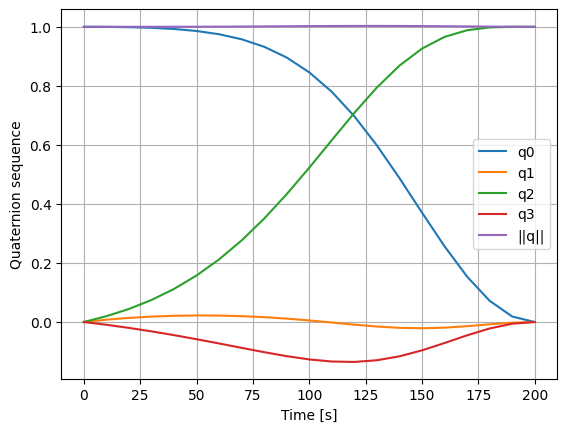

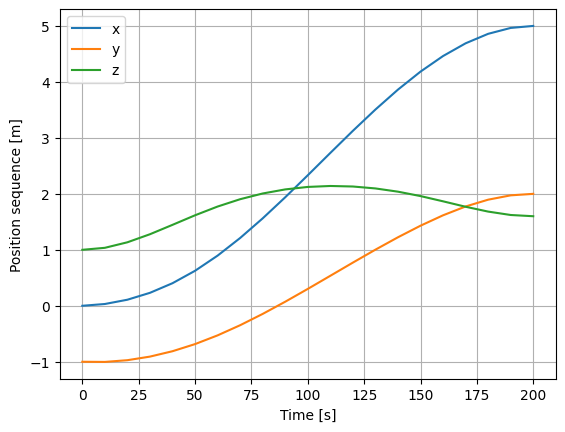

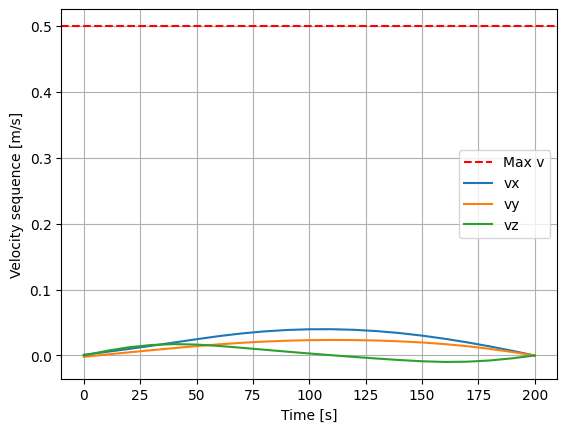

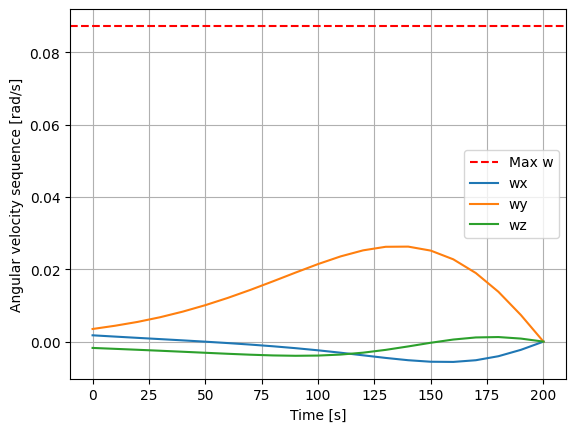

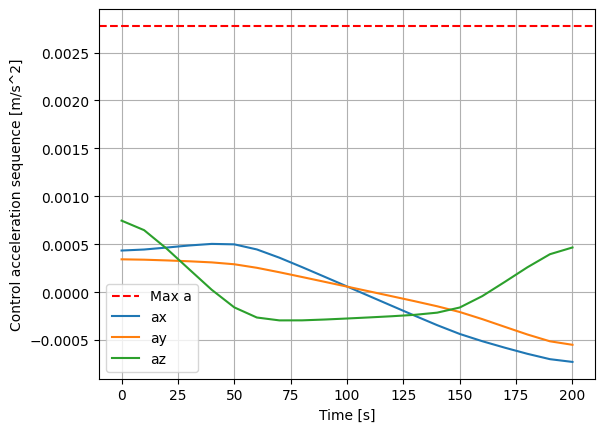

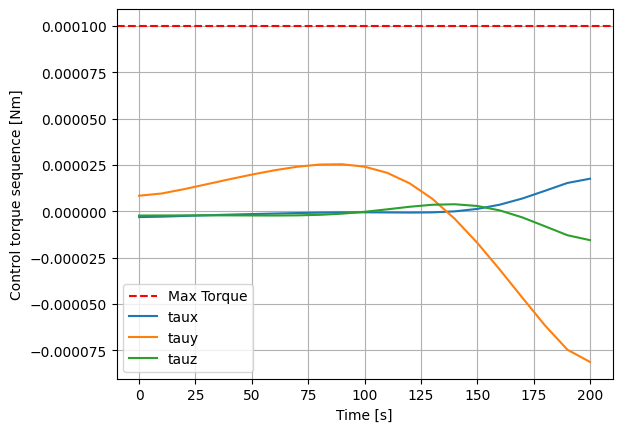

In [82]:
# Plot (scaled initial trajectories)
def global_inv_scaling(x,S,c,T):
    for i in range(0,T,1):
        x[:,i:i+1]=S@x[:,i:i+1]+c
    return x

#Uncomment if there is no optimal solution (or keyboard interruption)

#x_value=global_inv_scaling(np.copy(ox),S_x_scaling_double,c_x_scaling_double,T+1)
#u_value=global_inv_scaling(np.copy(ou),S_u_scaling_double,c_u_scaling_double,T)

x_value=global_inv_scaling(np.copy(ox),S_x_scaling_double,c_x_scaling_double,T+1)
u_value=global_inv_scaling(np.copy(ou),S_u_scaling_double,c_u_scaling_double,T+1)

plt.figure(1)
plt.plot(np.linspace(0, tf, T+1), x_value[6,:], label='q0')
plt.plot(np.linspace(0, tf, T+1), x_value[7,:], label='q1')
plt.plot(np.linspace(0, tf, T+1), x_value[8,:], label='q2')
plt.plot(np.linspace(0, tf, T+1), x_value[9,:], label='q3')
plt.plot(np.linspace(0, tf, T+1), np.linalg.norm(x_value[6:10,:],axis=0), label='||q||')
plt.ylabel('Quaternion sequence')
plt.xlabel('Time [s]')
plt.gca().tick_params(labelsize=10)
plt.legend()
plt.grid(True)

plt.figure(2)
plt.plot(np.linspace(0, tf, T+1), x_value[0,:], label='x')
plt.plot(np.linspace(0, tf, T+1), x_value[1,:], label='y')
plt.plot(np.linspace(0, tf, T+1), x_value[2,:], label='z')

plt.ylabel('Position sequence [m]')
plt.xlabel('Time [s]')
plt.gca().tick_params(labelsize=10)
plt.legend()
plt.grid(True)

plt.figure(3)
plt.axhline(y=vel_max_double, color='r', linestyle='--', label='Max v')
plt.plot(np.linspace(0, tf, T+1), x_value[3,:], label='vx')
plt.plot(np.linspace(0, tf, T+1), x_value[4,:], label='vy')
plt.plot(np.linspace(0, tf, T+1), x_value[5,:], label='vz')

plt.ylabel('Velocity sequence [m/s]')
plt.xlabel('Time [s]')
plt.gca().tick_params(labelsize=10)
plt.legend()
plt.grid(True)


plt.figure(4)
plt.axhline(y=omega_max_double, color='r', linestyle='--', label='Max w')
plt.plot(np.linspace(0, tf, T+1), x_value[10,:], label='wx')
plt.plot(np.linspace(0, tf, T+1), x_value[11,:], label='wy')
plt.plot(np.linspace(0, tf, T+1), x_value[12,:], label='wz')

plt.ylabel('Angular velocity sequence [rad/s]')
plt.xlabel('Time [s]')
plt.gca().tick_params(labelsize=10)
plt.legend()
plt.grid(True)

plt.figure(5)
plt.axhline(y=acc_max_double, color='r', linestyle='--', label='Max a')
plt.plot(np.linspace(0, tf, T+1), u_value[0,:], label='ax')
plt.plot(np.linspace(0, tf, T+1), u_value[1,:], label='ay')
plt.plot(np.linspace(0, tf, T+1), u_value[2,:], label='az')

plt.ylabel('Control acceleration sequence [m/s^2]')
plt.xlabel('Time [s]')
plt.gca().tick_params(labelsize=10)
plt.legend()
plt.grid(True)

plt.figure(6)
plt.axhline(y=torq_max_double, color='r', linestyle='--', label='Max Torque')
plt.plot(np.linspace(0, tf, T+1), u_value[3,:], label='taux')
plt.plot(np.linspace(0, tf, T+1), u_value[4,:], label='tauy')
plt.plot(np.linspace(0, tf, T+1), u_value[5,:], label='tauz')

plt.ylabel('Control torque sequence [Nm]')
plt.xlabel('Time [s]')
plt.gca().tick_params(labelsize=10)
plt.legend()
plt.grid(True)

In [34]:
def create_cube(center, size, quaternion):
    """Creates a rotated cube using a quaternion."""
    half = size / 2.0
    vertices = np.array([  # Cube vertices
        [-half, -half, -half], [half, -half, -half], [half, half, -half], [-half, half, -half],
        [-half, -half, half], [half, -half, half], [half, half, half], [-half, half, half]
    ])

    # Apply rotation using quaternion
    r = R.from_quat(quaternion)
    rotated_vertices = r.apply(vertices) + center

    # Cube faces (each face as a set of 4 vertices)
    faces = [
        [0, 1, 2, 3], [4, 5, 6, 7], [0, 1, 5, 4],
        [2, 3, 7, 6], [0, 3, 7, 4], [1, 2, 6, 5]
    ]

    # Define mesh faces for the cube
    i_faces = [face[0] for face in faces]
    j_faces = [face[1] for face in faces]
    k_faces = [face[2] for face in faces]
    i_faces += [face[0] for face in faces]
    j_faces += [face[2] for face in faces]
    k_faces += [face[3] for face in faces]

    # Mesh3d for the cube (white cube)
    cube = go.Mesh3d(
        x=rotated_vertices[:, 0], y=rotated_vertices[:, 1], z=rotated_vertices[:, 2],
        i=i_faces, j=j_faces, k=k_faces, opacity=1.0, color='white'
    )

    # Create "eyes" (small blue circles) on the cube's faces
    eye_radius = 0.1
    eye_positions = [
        [half,0.13,0], [half,-0.13,0]
    ]

    # Apply rotation to eye positions
    rotated_eye_positions = r.apply(eye_positions) + center

    eye_spheres = []
    for pos in rotated_eye_positions:
        u, v = np.mgrid[0:2*np.pi:10j, 0:np.pi:5j]
        x_eye = eye_radius * np.cos(u) * np.sin(v) + pos[0]
        y_eye = eye_radius * np.sin(u) * np.sin(v) + pos[1]
        z_eye = eye_radius * np.cos(v) + pos[2]

        # Crear una matriz de color uniforme (por ejemplo, azul con un solo valor)
        color_value = np.full_like(x_eye, 0.5)  # 0.5 es un tono de azul en la escala

        eye_spheres.append(go.Surface(
            x=x_eye, y=y_eye, z=z_eye, surfacecolor=color_value,
            colorscale=[[0, 'deepskyblue'], [1, 'deepskyblue']], opacity=1.0, showscale=False
        ))

    return cube, eye_spheres

def create_spheres(spheres):
    """Creates spheres as surfaces."""
    sphere_traces = []
    for sphere in spheres:
        h, rc = sphere['h'], sphere['rc']
        u, v = np.mgrid[0:2*np.pi:16j, 0:np.pi:8j]
        x_sphere = rc * np.cos(u) * np.sin(v) + h[0]
        y_sphere = rc * np.sin(u) * np.sin(v) + h[1]
        z_sphere = rc * np.cos(v) + h[2]
        sphere_traces.append(go.Surface(
            x=x_sphere, y=y_sphere, z=z_sphere, colorscale='Reds', opacity=0.3, showscale=False
        ))
    return sphere_traces

def plot_3d_trajectory_with_cube(x_value, spheres):
    quaternions = x_value[6:10, :]
    x_traj, y_traj, z_traj = x_value[0, :], x_value[1, :], x_value[2, :]

    trace_trajectory = go.Scatter3d(x=x_traj, y=y_traj, z=z_traj, mode='lines',
                                    line=dict(color='blue', width=2))

    # Set axis limits with uniform scaling
    padding = 0.5
    max_range = max(max(x_traj) - min(x_traj), max(y_traj) - min(y_traj), max(z_traj) - min(z_traj)) / 2
    mid_x, mid_y, mid_z = (max(x_traj) + min(x_traj)) / 2, (max(y_traj) + min(y_traj)) / 2, (max(z_traj) + min(z_traj)) / 2
    x_range = [mid_x - max_range - padding, mid_x + max_range + padding]
    y_range = [mid_y - max_range - padding, mid_y + max_range + padding]
    z_range = [mid_z - max_range - padding, mid_z + max_range + padding]

    # Initial cube (white with blue eyes)
    cube, eye_spheres = create_cube([x_traj[0], y_traj[0], z_traj[0]], 0.5, quaternions[:, 0])

    # Initial spheres
    sphere_traces = create_spheres(spheres)

    # Animation frames
    frames = [
        go.Frame(data=[
            go.Scatter3d(x=x_traj, y=y_traj, z=z_traj, mode='lines',
                         marker=dict(size=2, color='blue')),
            create_cube([x_traj[k], y_traj[k], z_traj[k]], 0.5, quaternions[:, k])[0],
        ] + create_spheres(spheres) + create_cube([x_traj[k], y_traj[k], z_traj[k]], 0.5, quaternions[:, k])[1])
        for k in range(len(x_traj))
    ]

    layout = go.Layout(
        title='Astrobee guidance COGU (SCVx, ECOS)',
        scene=dict(
            xaxis_title='x', yaxis_title='y', zaxis_title='z',
            xaxis=dict(range=x_range, autorange=False),
            yaxis=dict(range=y_range, autorange=False),
            zaxis=dict(range=z_range, autorange=False),
            aspectmode='cube',  # Ensures correct proportions
            camera=dict(eye=dict(x=1.5, y=1.5, z=1.5))  # Adjust camera view for better visibility
        ),
        updatemenus=[dict(type='buttons', buttons=[dict(label='Play', method='animate',
                                                       args=[None, dict(frame=dict(duration=50, redraw=True),
                                                                        fromcurrent=True)])])])

    fig = go.Figure(data=[trace_trajectory, cube] + sphere_traces + eye_spheres, layout=layout, frames=frames)
    fig.show()

spheres = [
    {'h': c_obs1_double, 'rc': d_obs1_double},
    {'h': c_obs2_double, 'rc': d_obs2_double},
    {'h': c_obs3_double, 'rc': d_obs3_double}
]

plot_3d_trajectory_with_cube(x_value, spheres)

Execute the following code to copy and paste the most important .c and .h inside the folder "Astrobee_GuSTO_ECOS_T51_l2\matlab_copy".

In [ ]:
import os
import shutil
import re

def collect_files(source_folder):
    # Define the destination folder
    destination_folder = os.path.join(source_folder, 'matlab_copy')
    
    # Create the destination folder if it doesn't exist
    if not os.path.exists(destination_folder):
        os.makedirs(destination_folder)
    
    # Files to delete
    files_to_delete = ['runecos_exp.c', 'runecos.c','CMakeCCompilerId.c']
    
    # Files in which to replace 'pinv' with 'pinv2'
    files_to_replace = ['splamm.h', 'splamm.c', 'preproc.c']
    
    # Files to modify by removing "../../include/"
    files_to_modify = ['ldl.h', 'ldl.c']

    # Walk through the source folder and its subfolders
    for root, dirs, files in os.walk(source_folder):
        # Skip the destination folder
        if root == destination_folder:
            continue
        
        for file in files:
            file_path = os.path.join(root, file)
            
            if file.endswith('.c') or file.endswith('.h'):
                # Copy the file to the destination folder
                shutil.copy(file_path, destination_folder)
                print(f"Copied {file_path} to {destination_folder}")

    # After all files are copied, process the files in the destination folder
    for file in os.listdir(destination_folder):
        file_path = os.path.join(destination_folder, file)
        
        # Delete the specified files
        if file in files_to_delete:
            os.remove(file_path)
            print(f"Deleted {file_path}")
            continue
        
        # Modify ldl.h and ldl.c files to remove "../../include/"
        if file in files_to_modify:
            with open(file_path, 'r') as f:
                content = f.read()
            content = content.replace('../../include/', '')
            with open(file_path, 'w') as f:
                f.write(content)
            print(f"Modified {file} to remove '../../include/'")
        
        # Replace 'pinv' function calls with 'pinv2' in specified files
        if file in files_to_replace:
            with open(file_path, 'r') as f:
                content = f.read()
            content = re.sub(r'\bpinv\b\s*\(', 'pinv2(', content)
            with open(file_path, 'w') as f:
                f.write(content)
            print(f"Replaced 'pinv' function calls with 'pinv2' in {file}")

# Usage example
source_folder = 'Astrobee_GuSTO_ECOS_T51_l2'
collect_files(source_folder)

Copied Astrobee_SCVX_ECOS_T51_l2\c\build\CMakeFiles\4.2.1\CompilerIdC\CMakeCCompilerId.c to Astrobee_SCVX_ECOS_T51_l2\matlab_copy
Copied Astrobee_SCVX_ECOS_T51_l2\c\include\cpg_solve.h to Astrobee_SCVX_ECOS_T51_l2\matlab_copy
Copied Astrobee_SCVX_ECOS_T51_l2\c\include\cpg_workspace.h to Astrobee_SCVX_ECOS_T51_l2\matlab_copy
Copied Astrobee_SCVX_ECOS_T51_l2\c\solver_code\ecos_bb\ecos_bb.c to Astrobee_SCVX_ECOS_T51_l2\matlab_copy
Copied Astrobee_SCVX_ECOS_T51_l2\c\solver_code\ecos_bb\ecos_bb_preproc.c to Astrobee_SCVX_ECOS_T51_l2\matlab_copy
Copied Astrobee_SCVX_ECOS_T51_l2\c\solver_code\external\amd\include\amd.h to Astrobee_SCVX_ECOS_T51_l2\matlab_copy
Copied Astrobee_SCVX_ECOS_T51_l2\c\solver_code\external\amd\include\amd_internal.h to Astrobee_SCVX_ECOS_T51_l2\matlab_copy
Copied Astrobee_SCVX_ECOS_T51_l2\c\solver_code\external\amd\src\amd_1.c to Astrobee_SCVX_ECOS_T51_l2\matlab_copy
Copied Astrobee_SCVX_ECOS_T51_l2\c\solver_code\external\amd\src\amd_2.c to Astrobee_SCVX_ECOS_T51_l2\m

In [ ]:
ax, ay, az = sp.symbols('ax ay az')
taux, tauy, tauz = sp.symbols('taux tauy tauz')

t = sp.symbols('t')

rx, ry, rz = sp.symbols('rx ry rz')
vx, vy, vz = sp.symbols('vx vy vz')

q0, q1, q2, q3 = sp.symbols('q0 q1 q2 q3')
wx, wy, wz = sp.symbols('wx wy wz')

Ixx, Iyy, Izz = sp.symbols('Ixx Iyy Izz')
Ixy, Ixz, Iyz = sp.symbols('Ixy Ixz Iyz')

d_obs1, d_obs2, d_obs3 = sp.symbols('d_obs1 d_obs2 d_obs3')
c_obs1_x, c_obs1_y, c_obs1_z = sp.symbols('c_obs1_x c_obs1_y c_obs1_z')
c_obs2_x, c_obs2_y, c_obs2_z = sp.symbols('c_obs2_x c_obs2_y c_obs2_z')
c_obs3_x, c_obs3_y, c_obs3_z = sp.symbols('c_obs3_x c_obs3_y c_obs3_z')

# Rigid body kinematics
I = sp.Matrix([
    [Ixx, Ixy, Ixz],
    [Ixy, Iyy, Iyz],
    [Ixz, Iyz, Izz]
])

w_sympy = sp.Matrix([wx, wy, wz])
tau_sympy = sp.Matrix([taux, tauy, tauz])

f_ridig_body = I.inv() * (- w_sympy.cross(I*w_sympy) + tau_sympy)

f_ridig_body = sp.simplify(f_ridig_body)

f1 = vx
f2 = vy
f3 = vz
f4 = ax
f5 = ay
f6 = az
f7 = 0.5 * (-wx*q1-wy*q2-wz*q3)
f8 = 0.5 * (+wx*q0+wz*q2-wy*q3)
f9 = 0.5 * (+wy*q0-wz*q1+wx*q3)
f10 = 0.5 * (wz*q0+wy*q1-wx*q2)
f11 = f_ridig_body[0]
f12 = f_ridig_body[1]
f13 = f_ridig_body[2]

diff1 = sp.Matrix([rx, ry, rz])-sp.Matrix([c_obs1_x, c_obs1_y, c_obs1_z])
diff2 = sp.Matrix([rx, ry, rz])-sp.Matrix([c_obs2_x, c_obs2_y, c_obs2_z])
diff3 = sp.Matrix([rx, ry, rz])-sp.Matrix([c_obs3_x, c_obs3_y, c_obs3_z])

g1 = -sp.sqrt(diff1.dot(diff1))+d_obs1
g2 = -sp.sqrt(diff2.dot(diff2))+d_obs2
g3 = -sp.sqrt(diff3.dot(diff3))+d_obs3

f_orig_opt_prob=[f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13]
g_orig_opt_prob=[g1,g2,g3]

x_states = [rx,ry,rz,vx,vy,vz,q0,q1,q2,q3,wx,wy,wz]
u_input = [ax,ay,az,taux,tauy,tauz]

states_size = len(x_states)
inputs_size = len(u_input)
non_convex_inequalities_size = len(g_orig_opt_prob)

# Open loop maneuver

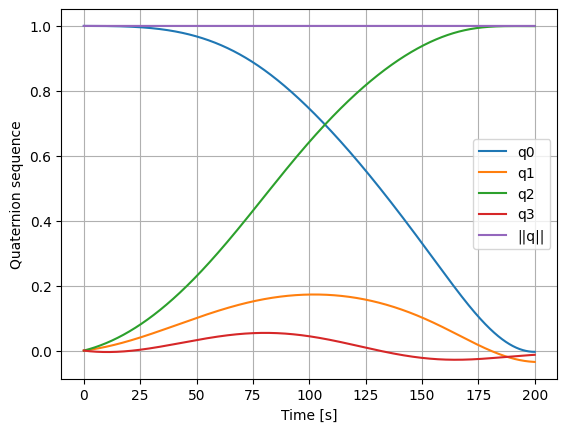

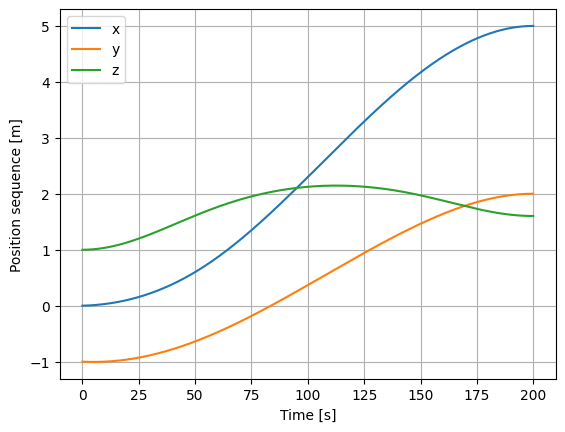

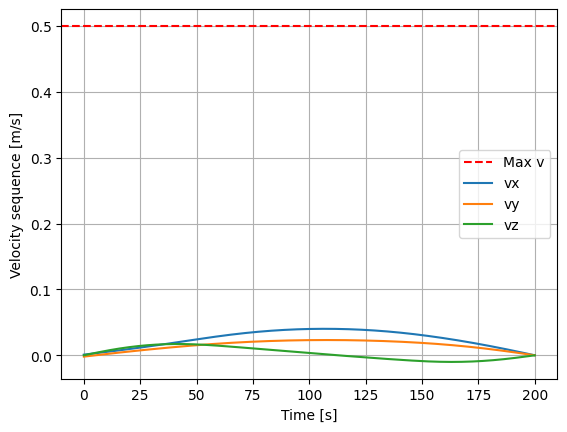

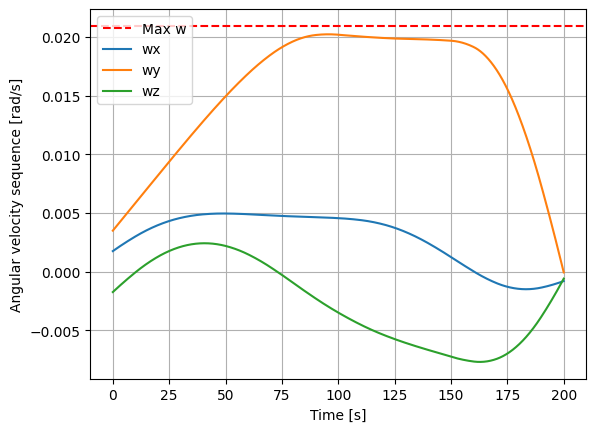

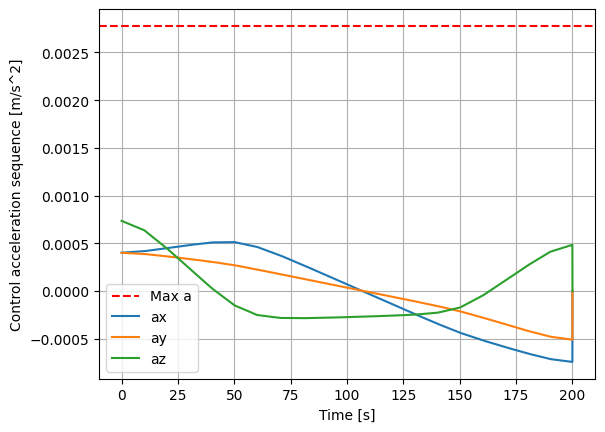

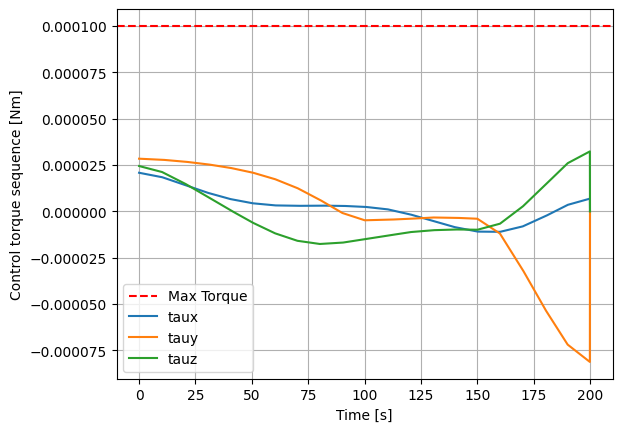

In [51]:
def dynamics_6dof(t, x, u, params):
    # =========================
    # States
    # =========================
    r = x[0:3]
    v = x[3:6]
    q = x[6:10]
    w = x[10:13]

    # =========================
    # Inputs (open-loop)
    # =========================
    a = u[0:3]        # translational acceleration
    tau = u[3:6]      # torque

    # =========================
    # Params
    # =========================
    I = params["I"]
    I_inv = params["I_inv"]

    # =========================
    # Translational dynamics
    # =========================
    r_dot = v
    v_dot = a

    # =========================
    # Quaternion kinematics
    # =========================
    q0, q1, q2, q3 = q
    wx, wy, wz = w

    q_dot = 0.5 * np.array([
        -wx*q1 - wy*q2 - wz*q3,
         wx*q0 + wz*q2 - wy*q3,
         wy*q0 - wz*q1 + wx*q3,
         wz*q0 + wy*q1 - wx*q2
    ])

    # =========================
    # Rigid body dynamics
    # =========================
    w_dot = I_inv @ (-np.cross(w, I @ w) + tau)

    return np.concatenate((r_dot, v_dot, q_dot, w_dot))

def rk4_step(f, t, x, u, dt, params):
    k1 = f(t, x, u, params)
    k2 = f(t + dt/2, x + dt/2 * k1, u, params)
    k3 = f(t + dt/2, x + dt/2 * k2, u, params)
    k4 = f(t + dt, x + dt * k3, u, params)

    x_next = x + dt/6 * (k1 + 2*k2 + 2*k3 + k4)

    # normalizar quaternion
    x_next[6:10] /= np.linalg.norm(x_next[6:10])

    return x_next

def u_interpol_linear(t, u_value, dt_control, t_lat=0.0):
    """
    Linear interpolation of control input after a latency time t_lat.
    
    Parameters
    ----------
    t : float
        Current simulation time
    u_value : ndarray shape (3, T_control)
        Discrete control samples
    dt_control : float
        Control sampling time
    t_lat : float
        Latency time before control starts [s]

    Returns
    -------
    u_interp : ndarray shape (3,)
        Interpolated control vector at time t
    """
    T_control = u_value.shape[1]

    if t < t_lat:
        # Antes de t_lat → mantener primer valor o cero
        return np.zeros(6)  # o np.zeros(3)
    
    # Ajustar tiempo relativo a t_lat
    t_rel = t - t_lat

    # Índice inferior
    index = int(np.floor(t_rel / dt_control))

    # Si estamos fuera del rango → mantener último valor
    if index >= T_control - 1:
        return np.zeros(6)

    # Tiempo local dentro del intervalo
    t0 = index * dt_control
    alpha = (t_rel - t0) / dt_control  # 0 ≤ alpha < 1

    # Interpolación lineal
    u0 = u_value[:, index]
    u1 = u_value[:, index + 1]
    
    return (1 - alpha) * u0 + alpha * u1

inertia_error = 0*Jxx_double*5/100

Jtrue = np.array([[Jxx_double+inertia_error,Jxy_double,Jxz_double],
                  [Jxy_double,Jyy_double-inertia_error,Jyz_double],
                  [Jxz_double,Jyz_double,Jzz_double+inertia_error]])

params = {
    "I": Jtrue,
    "I_inv": np.linalg.inv(Jtrue),
}

dt_state = 0.05
dt_control = tau_double
sim_time = tf

N = int(sim_time/dt_state) + 1

x = np.zeros(13)
x[0:3] = start_r_xyz[:,0]         # posición inicial
x[3:6] = start_v_xyz[:,0]        # velocidad inicial
x[6:10] = start_quat[:,0]  # quaternion
x[10:13] = start_w_xyz[:,0]      # angular velocity

x_history = np.zeros((N, 13))
u_history = np.zeros((N, 6))
t_history = np.zeros(N)

t = 0
t_lat = 0

for i in range(N):
    x_history[i] = x
    t_history[i] = t

    # interpolación (igual que antes)
    u_current = u_interpol_linear(t, u_value, dt_control, t_lat)

    u_history[i] = u_current

    x = rk4_step(dynamics_6dof, t, x, u_current, dt_state, params)

    t += dt_state


plt.figure(1)
plt.plot(np.linspace(0, sim_time, N), x_history[:,6], label='q0')
plt.plot(np.linspace(0, sim_time, N), x_history[:,7], label='q1')
plt.plot(np.linspace(0, sim_time, N), x_history[:,8], label='q2')
plt.plot(np.linspace(0, sim_time, N), x_history[:,9], label='q3')
plt.plot(np.linspace(0, sim_time, N), np.linalg.norm(x_history[:,6:10],axis=1), label='||q||')
plt.ylabel('Quaternion sequence')
plt.xlabel('Time [s]')
plt.gca().tick_params(labelsize=10)
plt.legend()
plt.grid(True)

plt.figure(2)
plt.plot(np.linspace(0, sim_time, N), x_history[:,0], label='x')
plt.plot(np.linspace(0, sim_time, N), x_history[:,1], label='y')
plt.plot(np.linspace(0, sim_time, N), x_history[:,2], label='z')

plt.ylabel('Position sequence [m]')
plt.xlabel('Time [s]')
plt.gca().tick_params(labelsize=10)
plt.legend()
plt.grid(True)

plt.figure(3)
plt.axhline(y=vel_max_double, color='r', linestyle='--', label='Max v')
plt.plot(np.linspace(0, sim_time, N), x_history[:,3], label='vx')
plt.plot(np.linspace(0, sim_time, N), x_history[:,4], label='vy')
plt.plot(np.linspace(0, sim_time, N), x_history[:,5], label='vz')

plt.ylabel('Velocity sequence [m/s]')
plt.xlabel('Time [s]')
plt.gca().tick_params(labelsize=10)
plt.legend()
plt.grid(True)


plt.figure(4)
plt.axhline(y=omega_max_double, color='r', linestyle='--', label='Max w')
plt.plot(np.linspace(0, sim_time, N), x_history[:,10], label='wx')
plt.plot(np.linspace(0, sim_time, N), x_history[:,11], label='wy')
plt.plot(np.linspace(0, sim_time, N), x_history[:,12], label='wz')

plt.ylabel('Angular velocity sequence [rad/s]')
plt.xlabel('Time [s]')
plt.gca().tick_params(labelsize=10)
plt.legend()
plt.grid(True)

plt.figure(5)
plt.axhline(y=acc_max_double, color='r', linestyle='--', label='Max a')
plt.plot(np.linspace(0, sim_time, N), u_history[:,0], label='ax')
plt.plot(np.linspace(0, sim_time, N), u_history[:,1], label='ay')
plt.plot(np.linspace(0, sim_time, N), u_history[:,2], label='az')

plt.ylabel('Control acceleration sequence [m/s^2]')
plt.xlabel('Time [s]')
plt.gca().tick_params(labelsize=10)
plt.legend()
plt.grid(True)

plt.figure(6)
plt.axhline(y=torq_max_double, color='r', linestyle='--', label='Max Torque')
plt.plot(np.linspace(0, sim_time, N), u_history[:,3], label='taux')
plt.plot(np.linspace(0, sim_time, N), u_history[:,4], label='tauy')
plt.plot(np.linspace(0, sim_time, N), u_history[:,5], label='tauz')

plt.ylabel('Control torque sequence [Nm]')
plt.xlabel('Time [s]')
plt.gca().tick_params(labelsize=10)
plt.legend()
plt.grid(True)

In [86]:
x_history[-1,6:10]

array([-0.06272237,  0.01312192,  0.99781094, -0.01634157])